In [1]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from scipy.special import expit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [9]:
df = pandas.read_csv(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=csv",
    parse_dates=["end_date"])
df = df[df["pollster"].notnull()].copy()
del df["url"]

In [10]:
df["partisan"].value_counts()

partisan
0           8
Sherrill    8
Spiller     5
Baraka      4
Fulop       3
Name: count, dtype: int64

In [11]:
cand_cols = ["Baraka", "Fulop", "Gottheimer", "Sherrill", "Spiller", "Sweeney"]
for col in cand_cols + ["Undecided"]:
    df[col] = df[col] * (df["sample_size"] / 100)
df["sample_size_adj"] = df["sample_size"] - df["Undecided"]
del df["Undecided"]
del df["sample_size"]
for col in cand_cols:
    df[col] = (df[col] / df["sample_size_adj"]) * 100

In [13]:
df = df.melt(
    id_vars=["pollster", "end_date", "population", "mode", "sample_size_adj", "moe", "kind", "partisan", "Weight", "credible_interval"],
    var_name="candidate", value_name="pct")

In [14]:
df["pct_lower"] = df["pct"] - df["moe"]
df["pct_upper"] = df["pct"] + df["moe"]
df["pct_lower"] = df["pct_lower"].apply(lambda x : 0 if x < 0 else x)

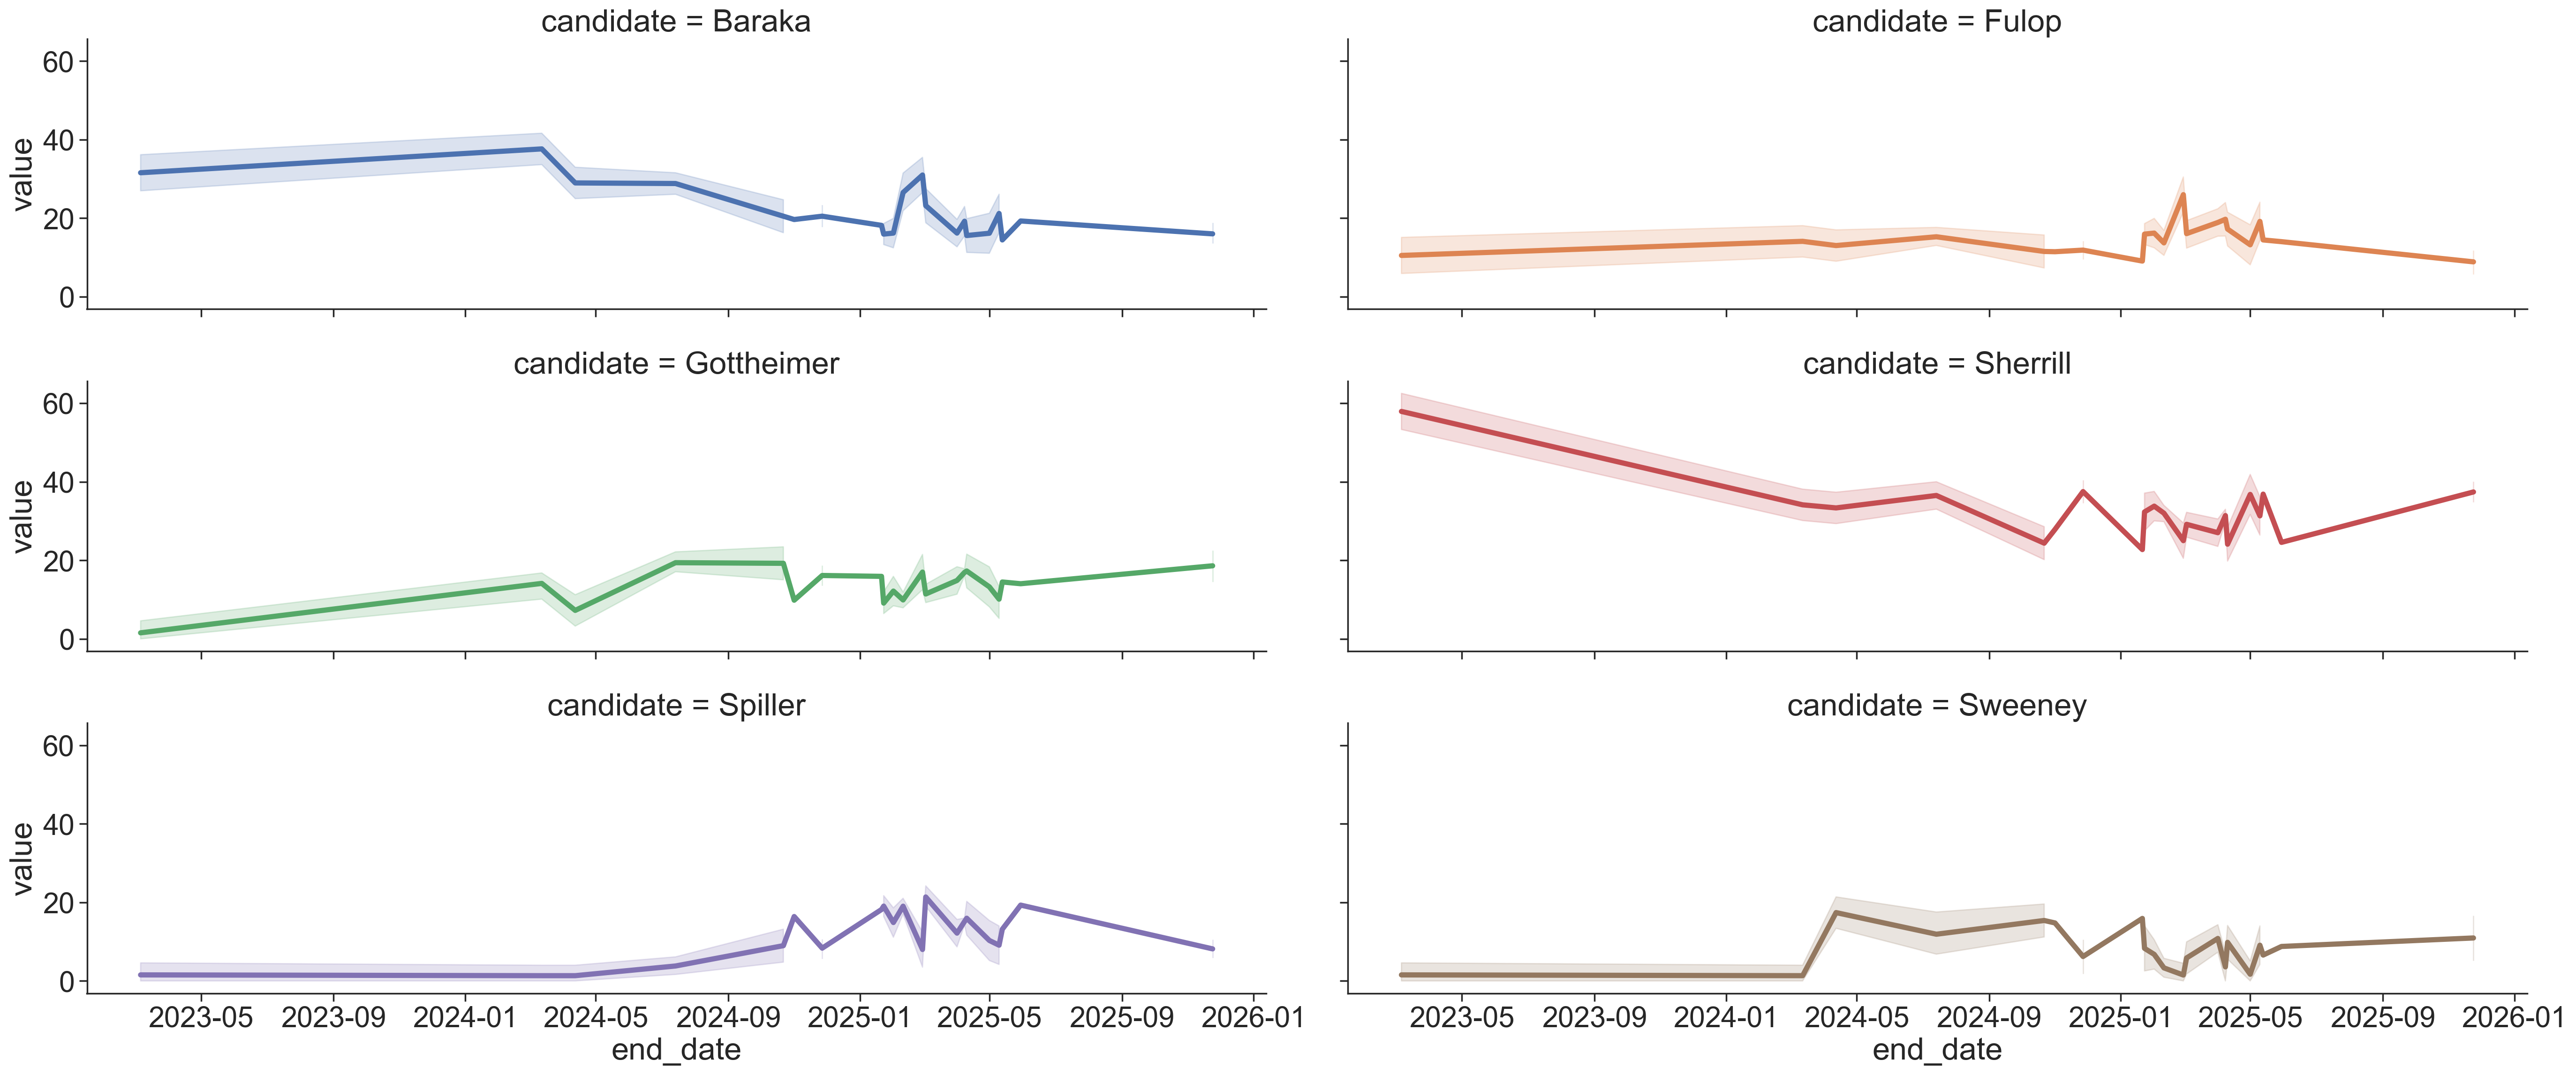

In [15]:
for_plot = df[["end_date", "candidate", "partisan", "pct", "pct_lower", "pct_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate", "partisan"])

ax = sns.relplot(data=for_plot[for_plot["candidate"] != "Undecided"], x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

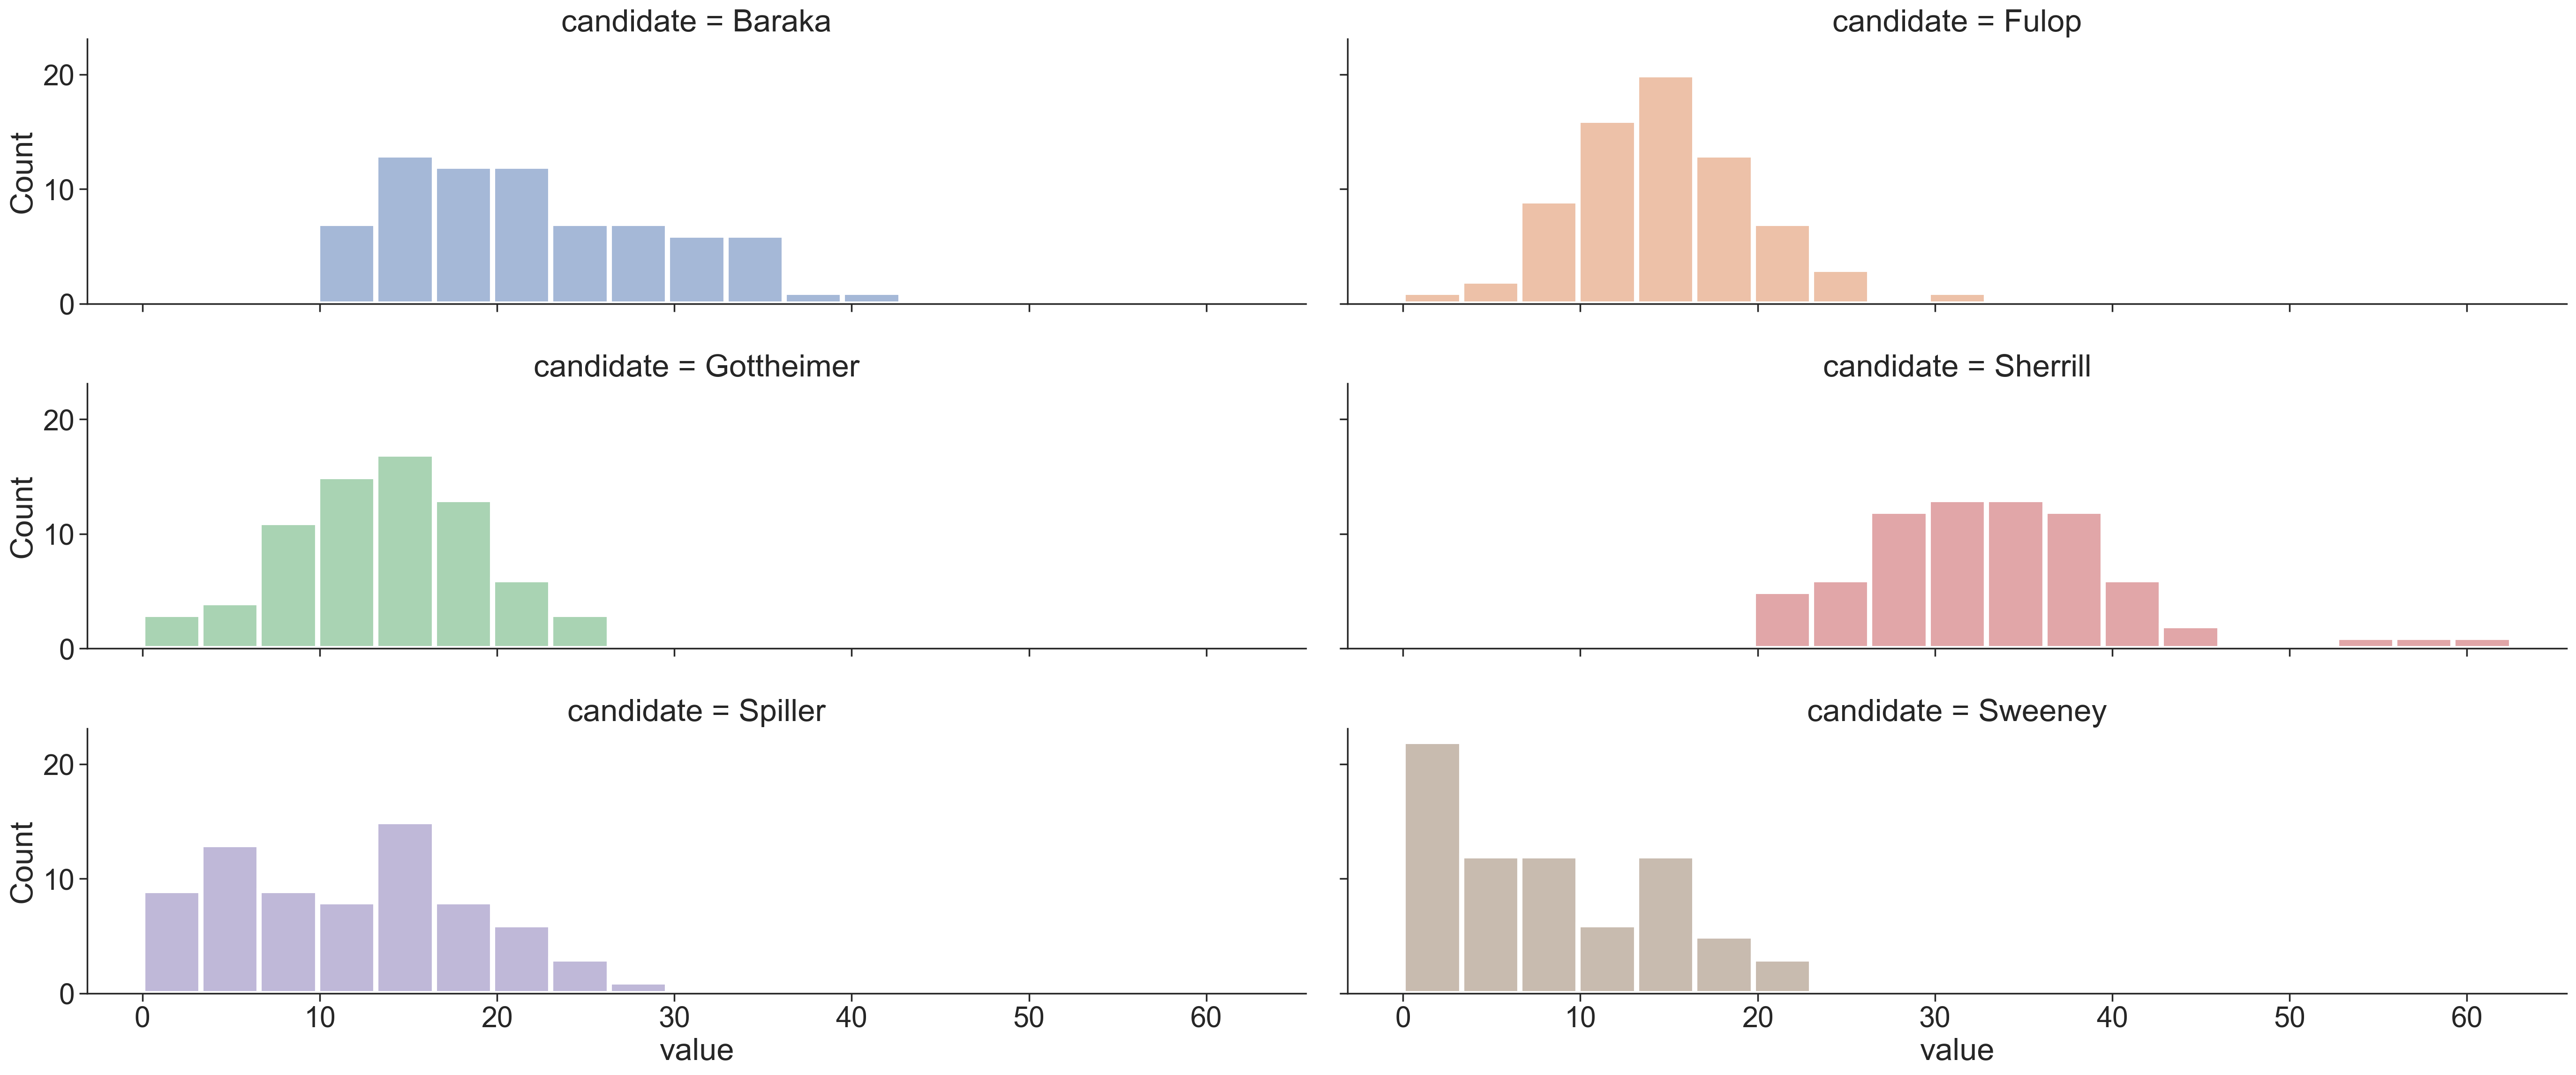

In [16]:
ax = sns.displot(data=for_plot, x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

In [17]:
(for_plot.groupby(["candidate", "partisan"]).agg({"value" : "mean"}).reset_index()
 .pivot(index="candidate", columns="partisan", values="value"))

partisan,0,Baraka,Fulop,Sherrill,Spiller
candidate,,,,,
Baraka,22.044269,27.688065,16.709918,22.880550,19.563393
Fulop,15.838407,14.498492,16.697259,12.281892,15.867037
Gottheimer,13.276055,14.647472,12.988164,15.316891,10.550138
Sherrill,32.893157,34.246347,30.043041,35.722164,30.258823
Spiller,9.644601,11.409883,13.924932,6.862677,20.136485
Sweeney,6.979394,7.603630,9.636686,8.308826,7.201045


In [18]:
df["num_for"] = ((df["pct"] / 100) * df["sample_size_adj"]).round(0)
df["num_for_lower"] = ((df["pct_lower"] / 100) * df["sample_size_adj"]).round(0)
df["num_for_upper"] = ((df["pct_upper"] / 100) * df["sample_size_adj"]).round(0)

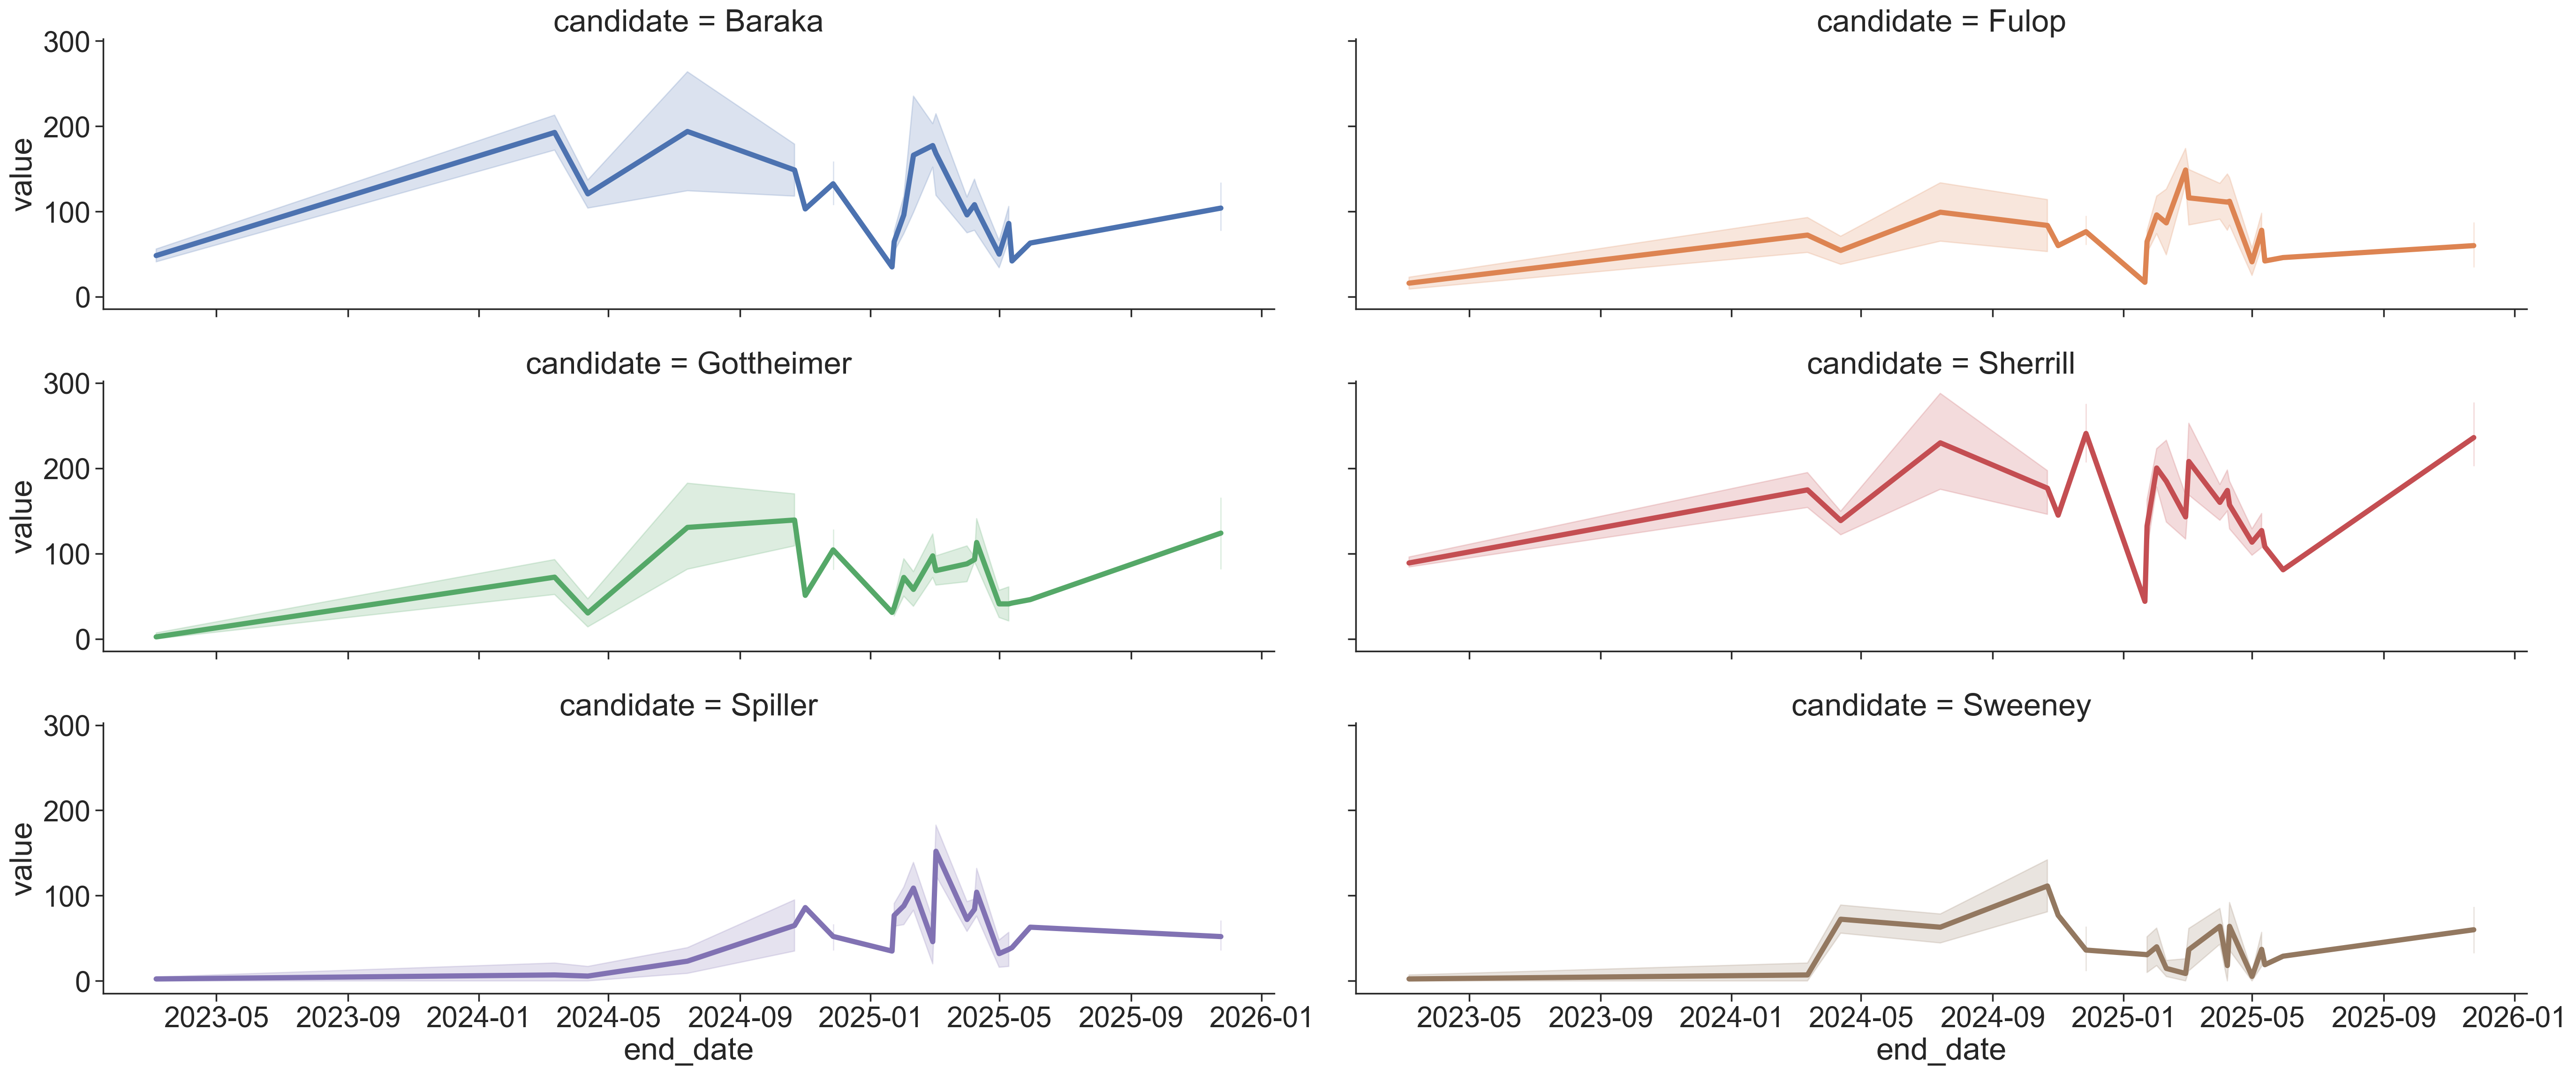

In [19]:
for_plot = df[["end_date", "candidate", "num_for", "num_for_lower", "num_for_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate"])

ax = sns.relplot(data=for_plot, x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

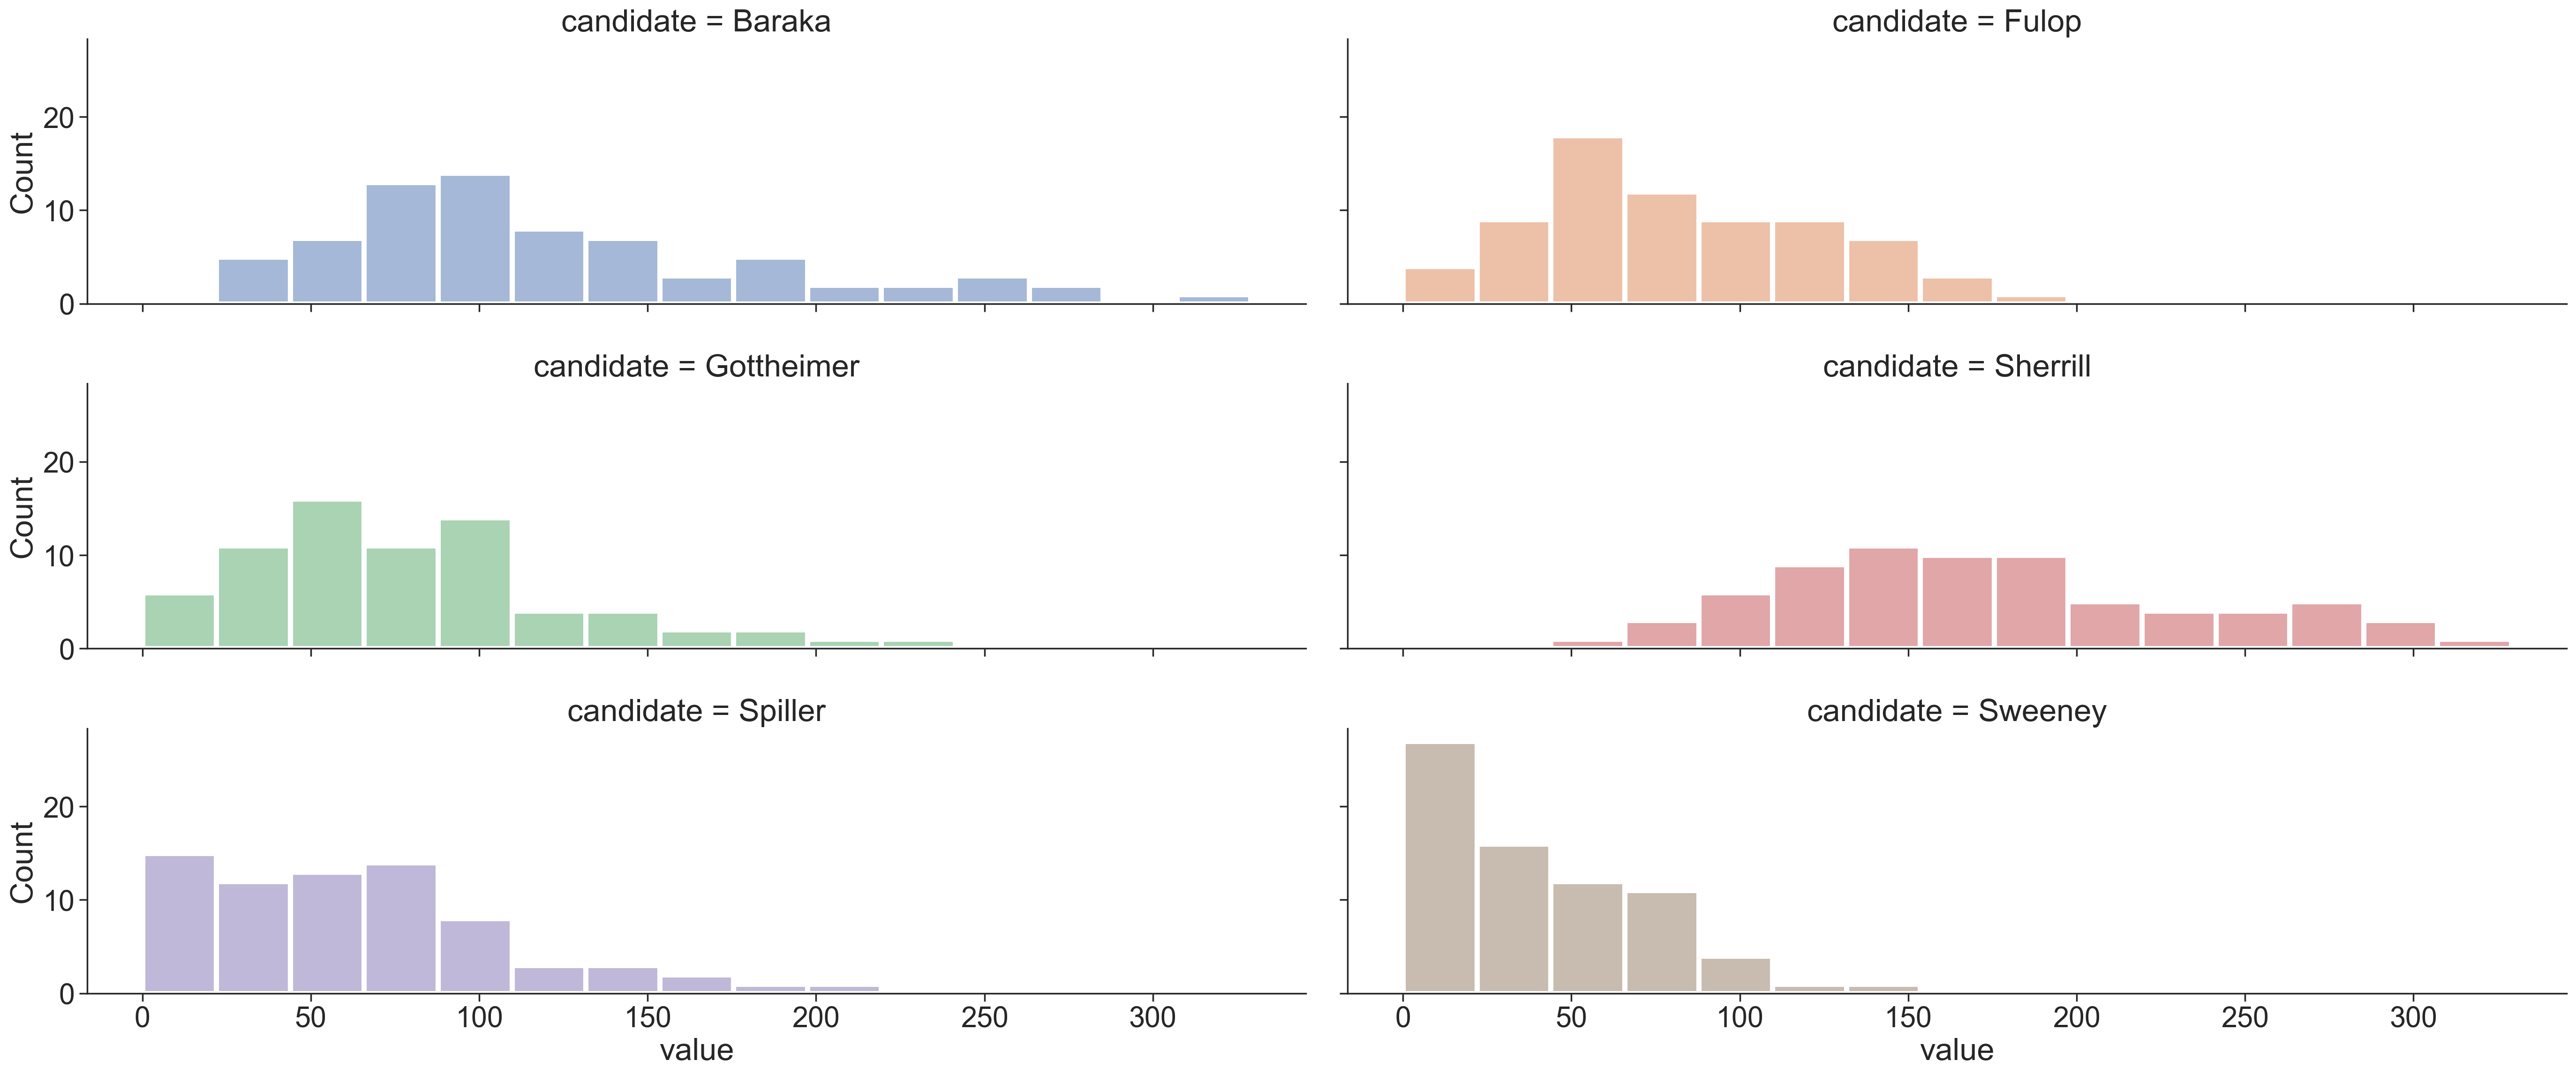

In [20]:
ax = sns.displot(data=for_plot, x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

---

In [21]:
# based on https://alexandorra.github.io/pollsposition_blog/popularity/macron/hidden%20markov%20models/polls/2021/05/16/hmm-popularity.html

In [22]:
df = df.melt(id_vars=[c for c in df.columns if not c.startswith("num_for")])
df = df.rename(columns={"value" : "num_for"})

In [23]:
df = df[df["pct_lower"].notnull()]

# Non-Partisan Polls Only

In [24]:
np_df = df[df["partisan"] == "0"].copy()

In [25]:
np_df["days_from_election"] = (pandas.to_datetime("2025-06-10") - np_df["end_date"]).dt.days

X_std = ((np_df["days_from_election"] - np_df["days_from_election"].min(axis=0)) /
         (np_df["days_from_election"].max(axis=0) - np_df["days_from_election"].min(axis=0)))
np_df["days_from_election"] = 1 - (X_std * (1 - 0.001) + 0.001)

In [26]:
cand_id, candidates = np_df["candidate"].factorize(sort=False)

In [27]:
np_df["mode_pop"] = np_df.apply(lambda x : " / ".join([x["mode"], x["population"]]), axis=1)
mode_pop_id, mode_pop = np_df["mode_pop"].factorize(sort=False)

In [28]:
coords = {
    "observation" : np_df.index,
    "candidate" : candidates,
    "mode_pop" : mode_pop
}

In [30]:
with pm.Model(coords=coords) as model:
    # month_effect = pm.Normal("month_effect", 0, 0.15, dims="month")
    mode_pop_effect = pm.Normal("mode_pop_effect", 0, 0.15, dims="mode_pop")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")
    time_until = pm.Deterministic("time_until", pt.as_tensor(np_df["days_from_election"].to_numpy()))

    popularity = pm.math.invlogit(time_until + mode_pop_effect[mode_pop_id] + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=np_df["sample_size_adj"],
        observed=np_df["num_for"],
        dims="observation",
    )

In [31]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mode_pop_effect, shrinkage_pop, candidate_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


/Users/napolitanod/miniconda3/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


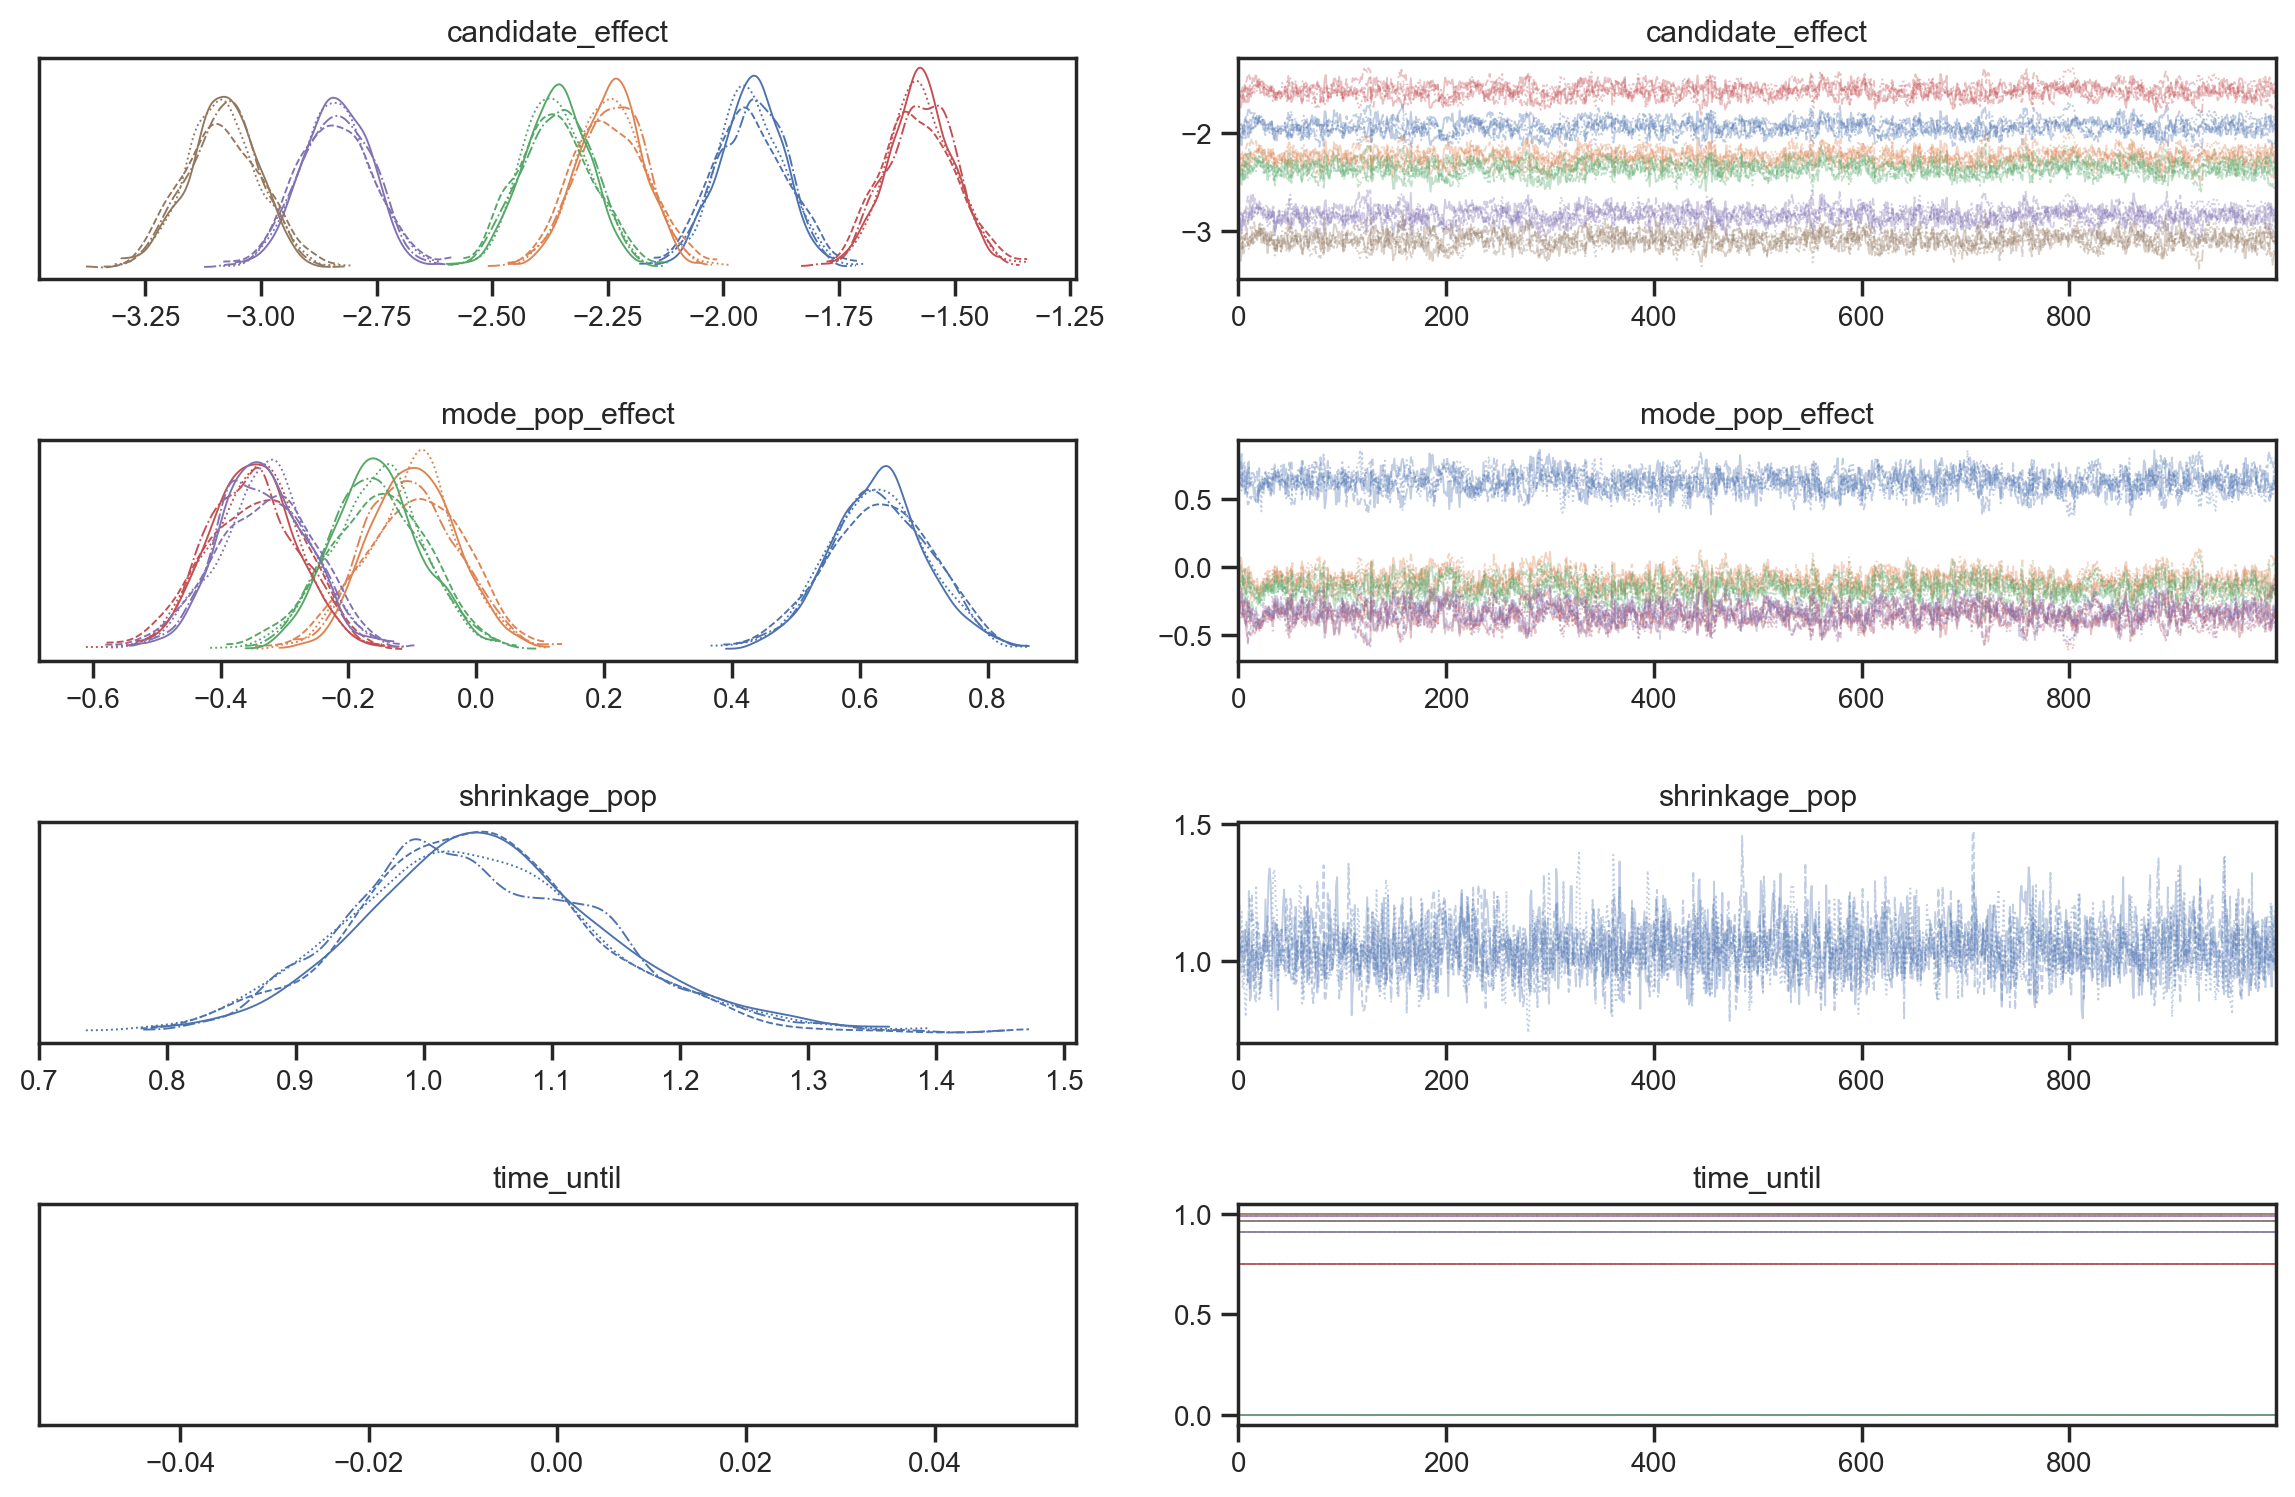

In [32]:
az.plot_trace(idata);
plt.tight_layout()

In [33]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [34]:
cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["time_until"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    cand_preds[str(c.values)] = post_pop.mean(axis=(0, 1))

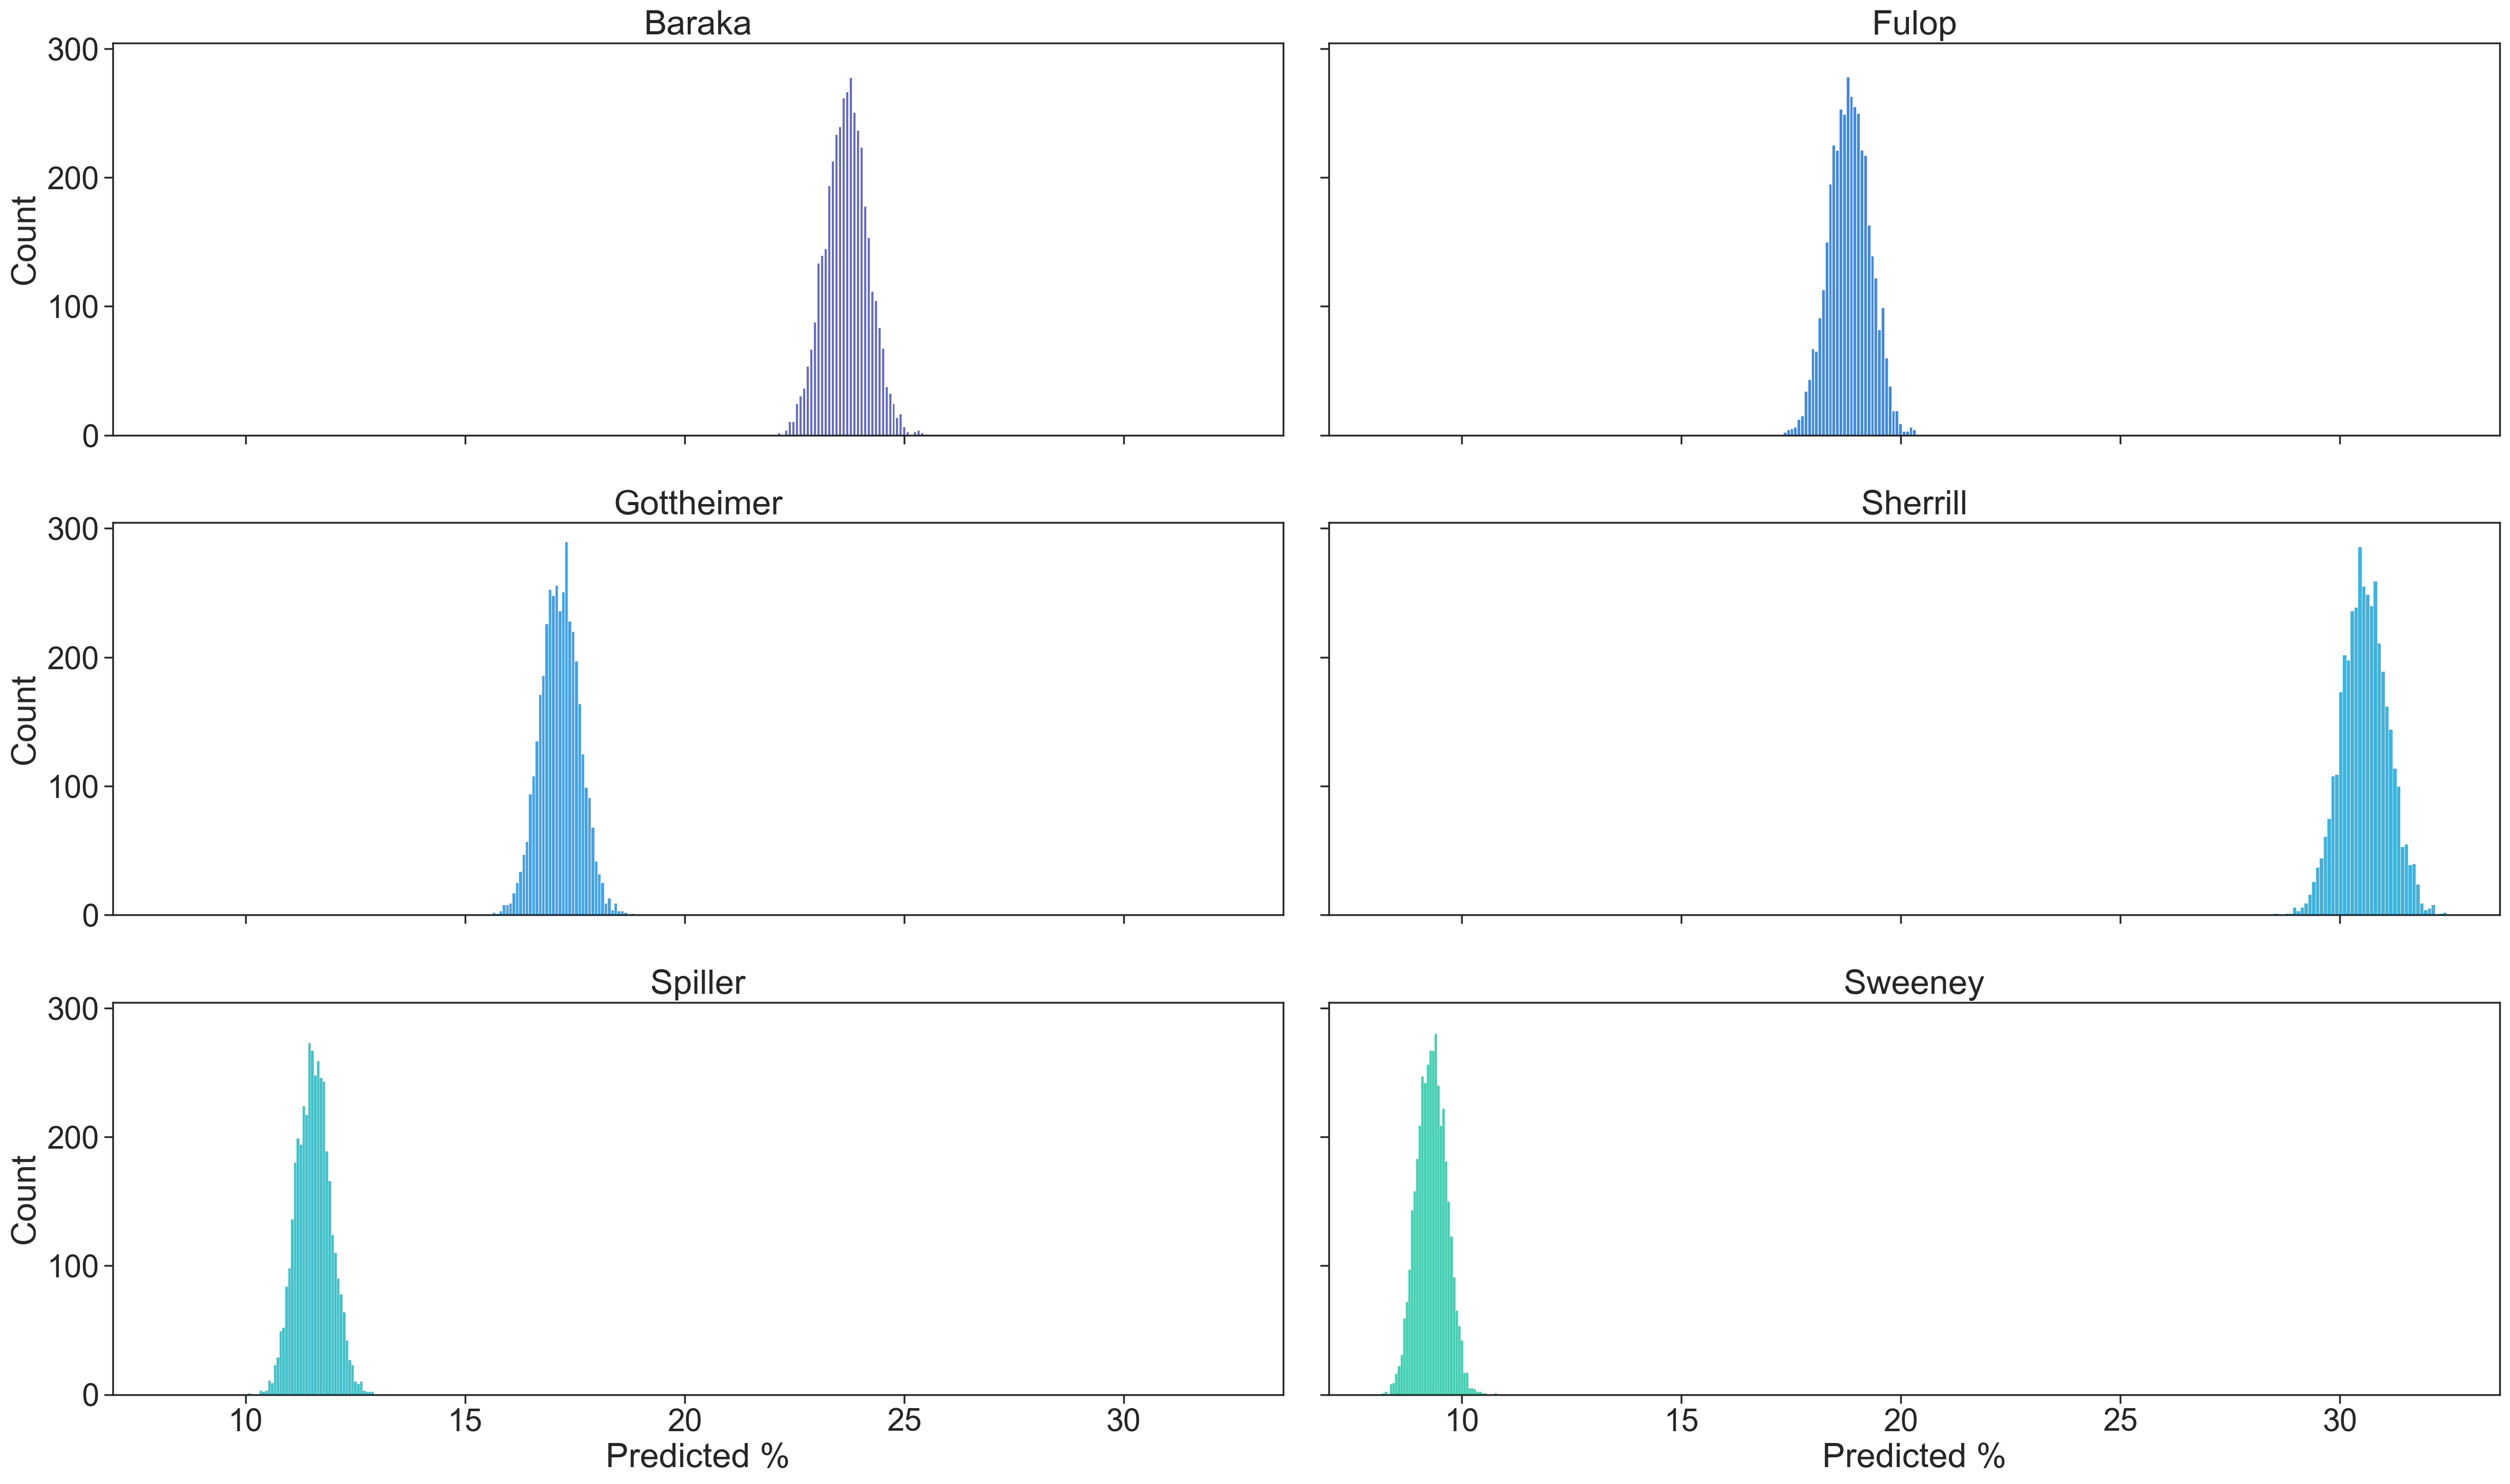

In [36]:
(fig, axs) = plt.subplots(3, 2, sharex=True, sharey=True)
colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]

for ((cand, ax), color) in zip(zip(cand_preds, axs.ravel()), colors):
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=color)
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")

plt.tight_layout()

In [37]:
rows = []
for cand in cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(cand_preds[cand].values),
           "Lower" : np.quantile(cand_preds[cand], 0.025),
           "Upper" : np.quantile(cand_preds[cand], 0.975)}
    rows.append(row)
np_pred_df = pandas.DataFrame(rows)

In [38]:
np_pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
3,Sherrill,0.305607,0.295272,0.316205
0,Baraka,0.236851,0.227142,0.246612
1,Fulop,0.188295,0.179247,0.197162
2,Gottheimer,0.171518,0.162760,0.180186
4,Spiller,0.115462,0.107974,0.123220
5,Sweeney,0.093105,0.086738,0.099683


# All Polls (Including Partisan)

In [39]:
cand_id, candidates = df["candidate"].factorize(sort=False)

In [40]:
partisan_id, partisans = df["partisan"].factorize(sort=False)

In [41]:
# TODO: figure out how to do a date decay that is hierarchical by partisanness...

df["end_month"] = df["end_date"].dt.to_period("M")
df["end_month_partisan"] = df.apply(lambda x : " / ".join([str(x["partisan"]), str(x["end_month"])]), axis=1)

(month_partisan_id, month_partisan) = df["end_month_partisan"].factorize(sort=False)

In [42]:
df["mode_pop"] = df.apply(lambda x : " / ".join([x["mode"], x["population"]]), axis=1)
mode_pop_id, mode_pop = df["mode_pop"].factorize(sort=False)

In [43]:
coords = {
    "observation" : df.index,
    "candidate" : candidates,
    "partisan" : partisans,
    "mode_pop" : mode_pop,
    "month_partisan" : month_partisan
}

In [44]:
with pm.Model(coords=coords) as model:
    partisan_effect = pm.TruncatedNormal("partisan_effect", mu=0.5, upper=1, lower=0, sigma=0.15, dims="partisan")
    mode_pop_effect = pm.Normal("mode_pop_effect", 0, 0.15, dims="mode_pop")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")
    month_partisan_effect = pm.Normal("month_partisan_effect", 0, 1, dims="month_partisan")
    
    popularity = pm.math.invlogit(partisan_effect[partisan_id]
                                  + month_partisan_effect[month_partisan_id]
                                  + mode_pop_effect[mode_pop_id]
                                  + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=df["sample_size_adj"],
        observed=df["num_for"],
        dims="observation",
    )

In [45]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [partisan_effect, mode_pop_effect, shrinkage_pop, candidate_effect, month_partisan_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


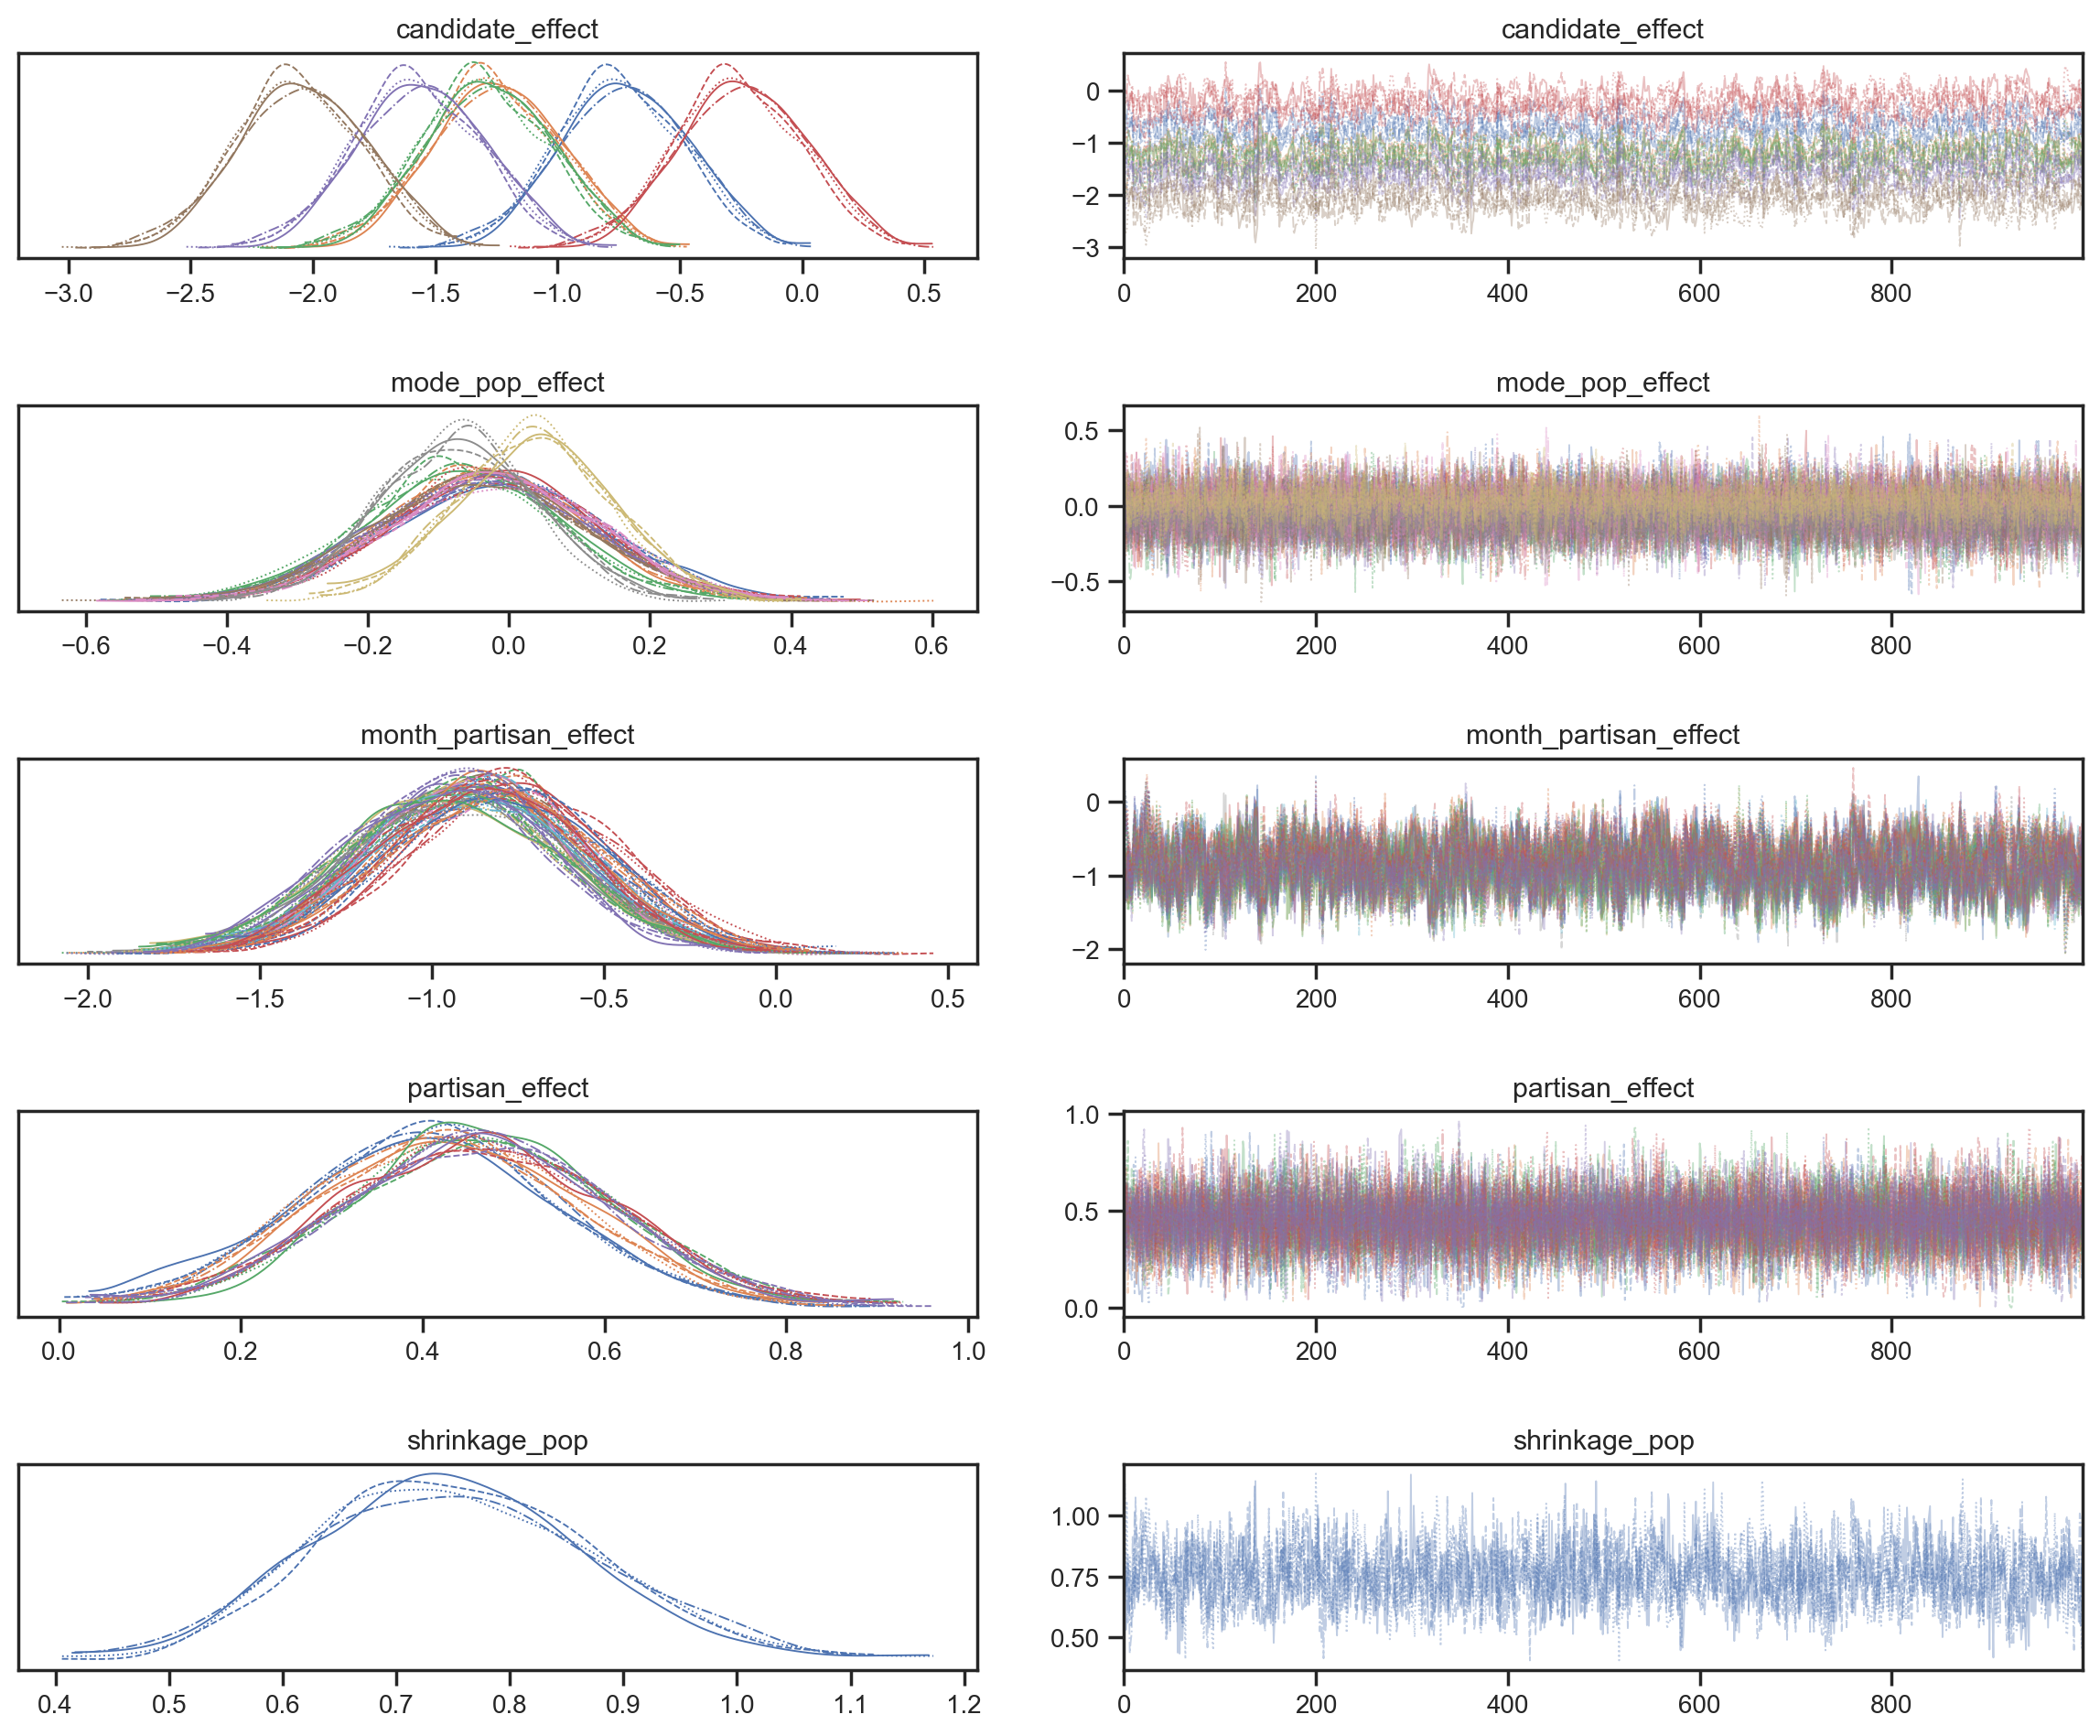

In [46]:
az.plot_trace(idata);
plt.tight_layout()

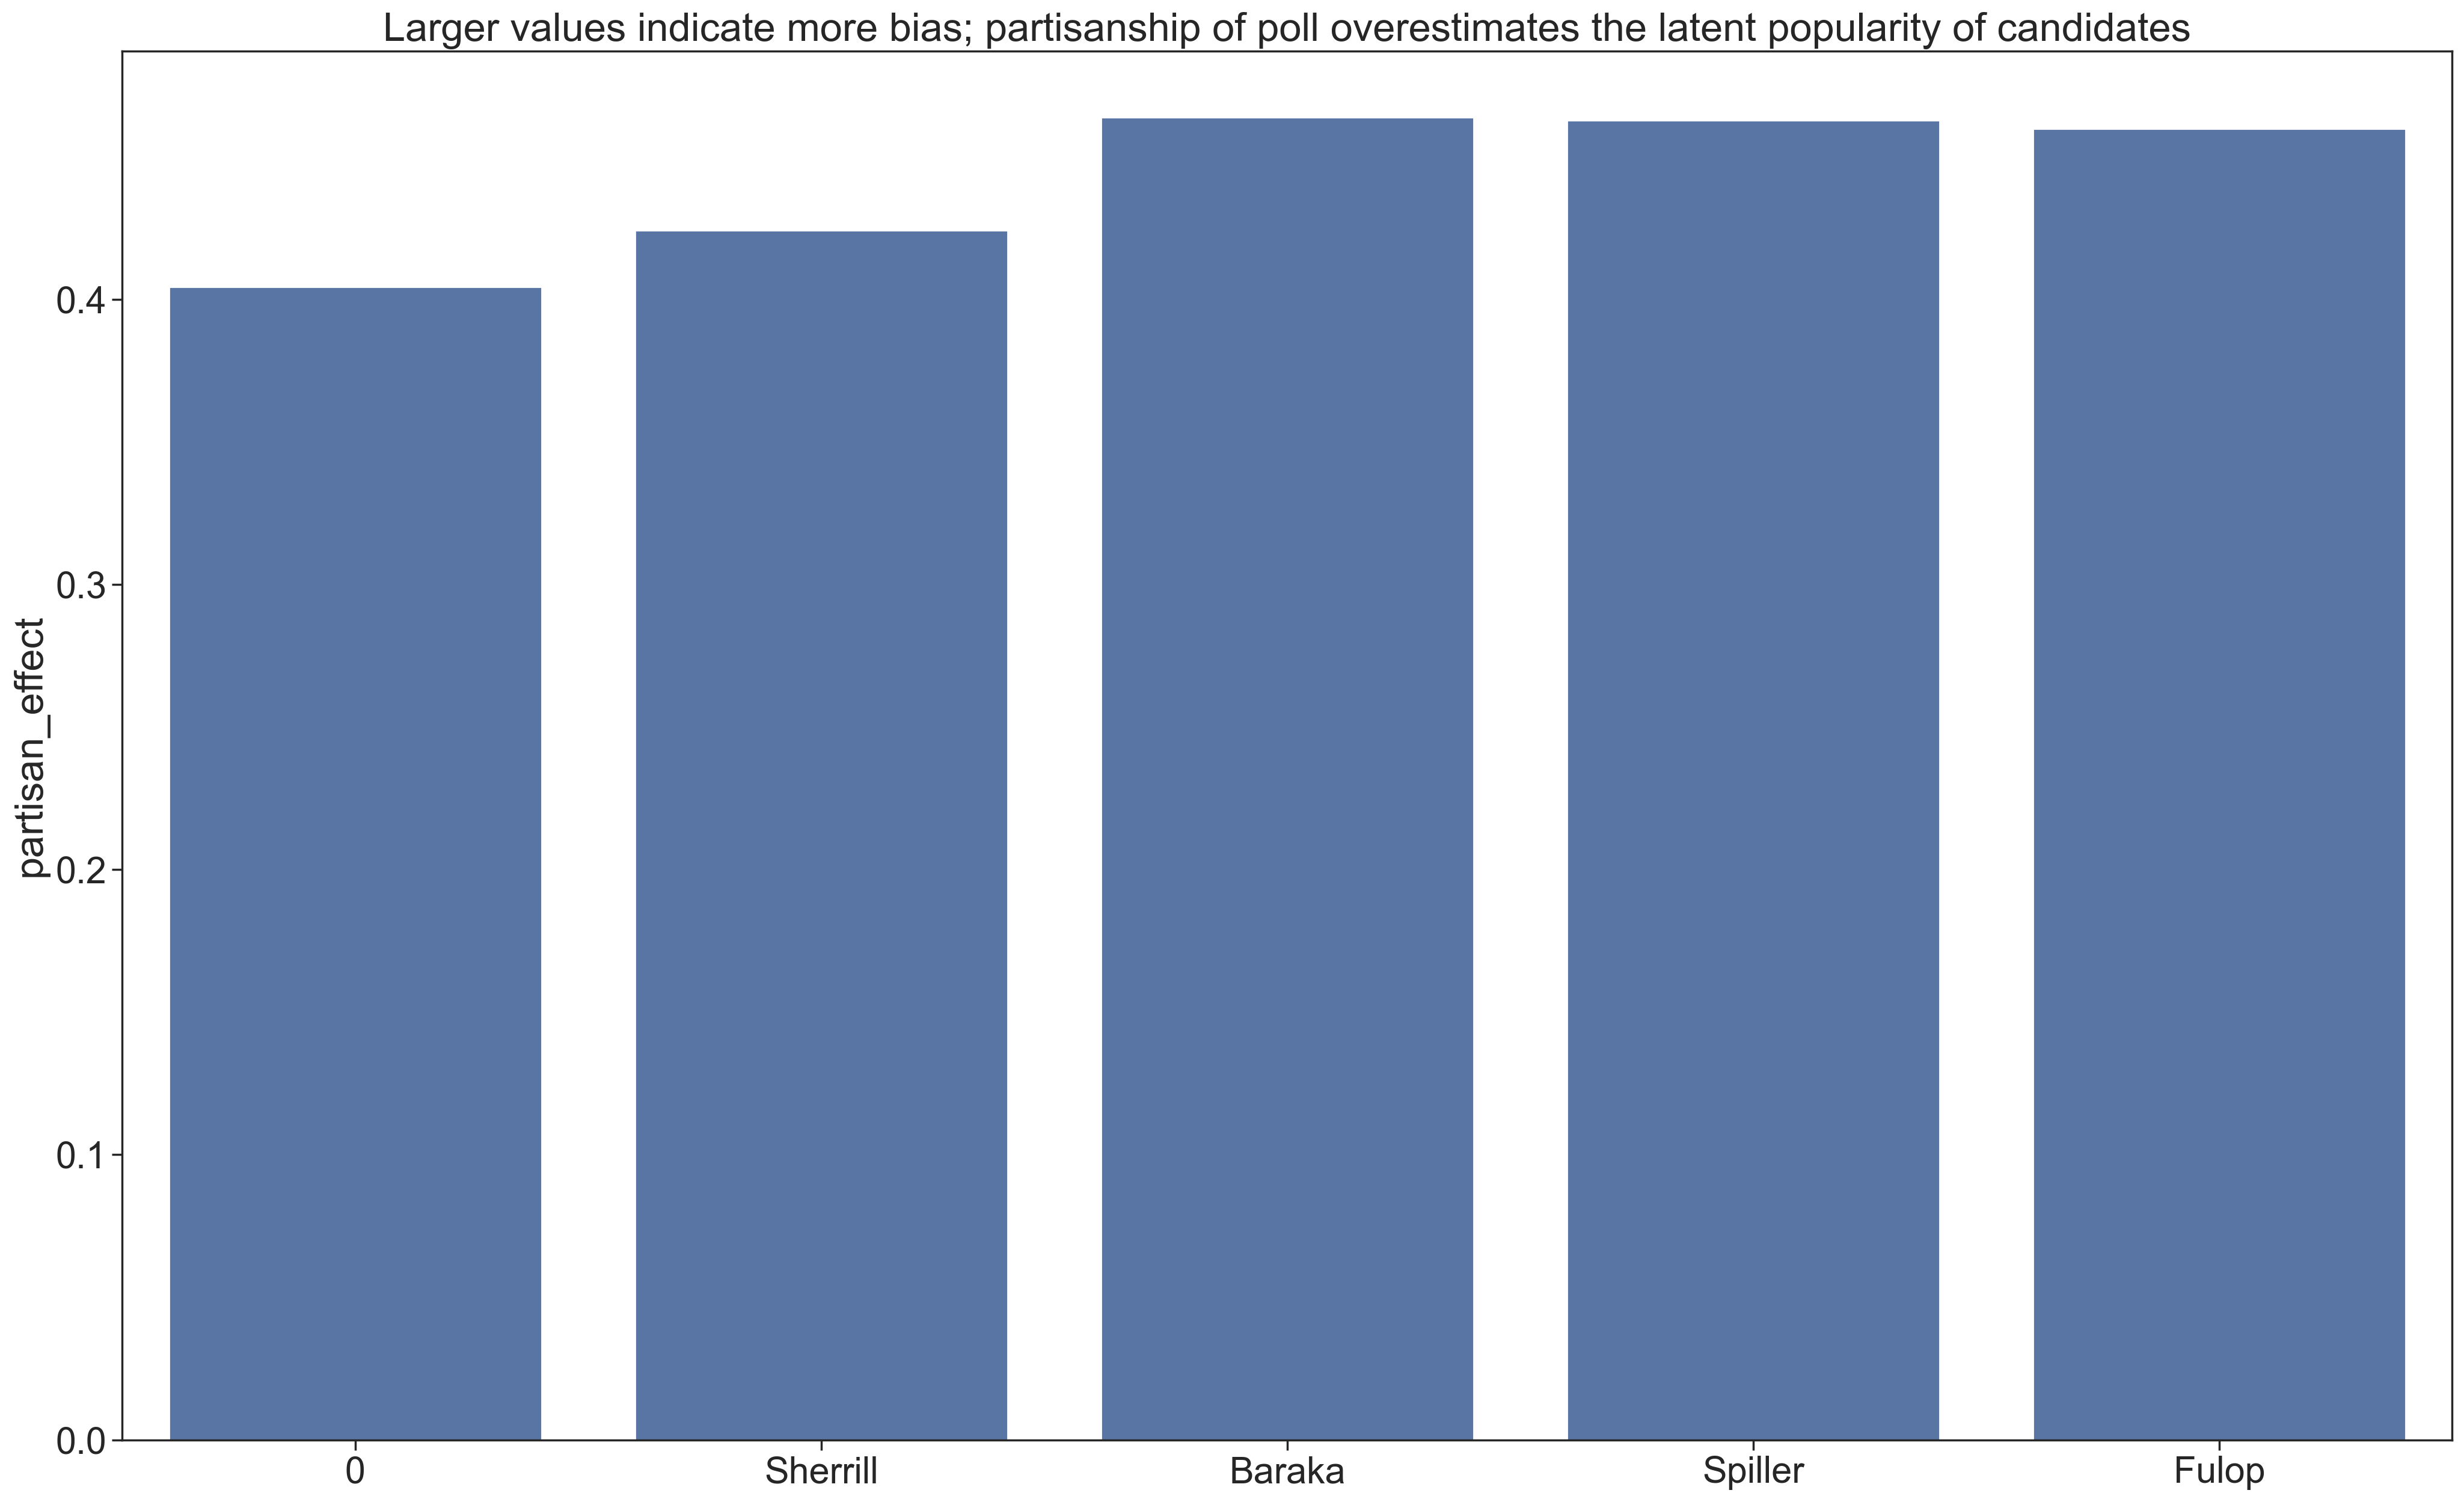

In [47]:
mean_kind_effect = (idata.posterior["partisan_effect"].mean(("chain", "draw")).to_dataframe()).reset_index()
ax = sns.barplot(data=mean_kind_effect, x="partisan", y="partisan_effect")
# ax.axhline(0, color="black", linestyle="--", linewidth=2)
ax.set_title("Larger values indicate more bias; partisanship of poll overestimates the latent popularity of candidates")
ax.set_xlabel(None)
plt.show()

In [48]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [49]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_partisan_effect"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = dict(zip(post["partisan"].values, post_pop.mean(axis=(1, 2)).values))

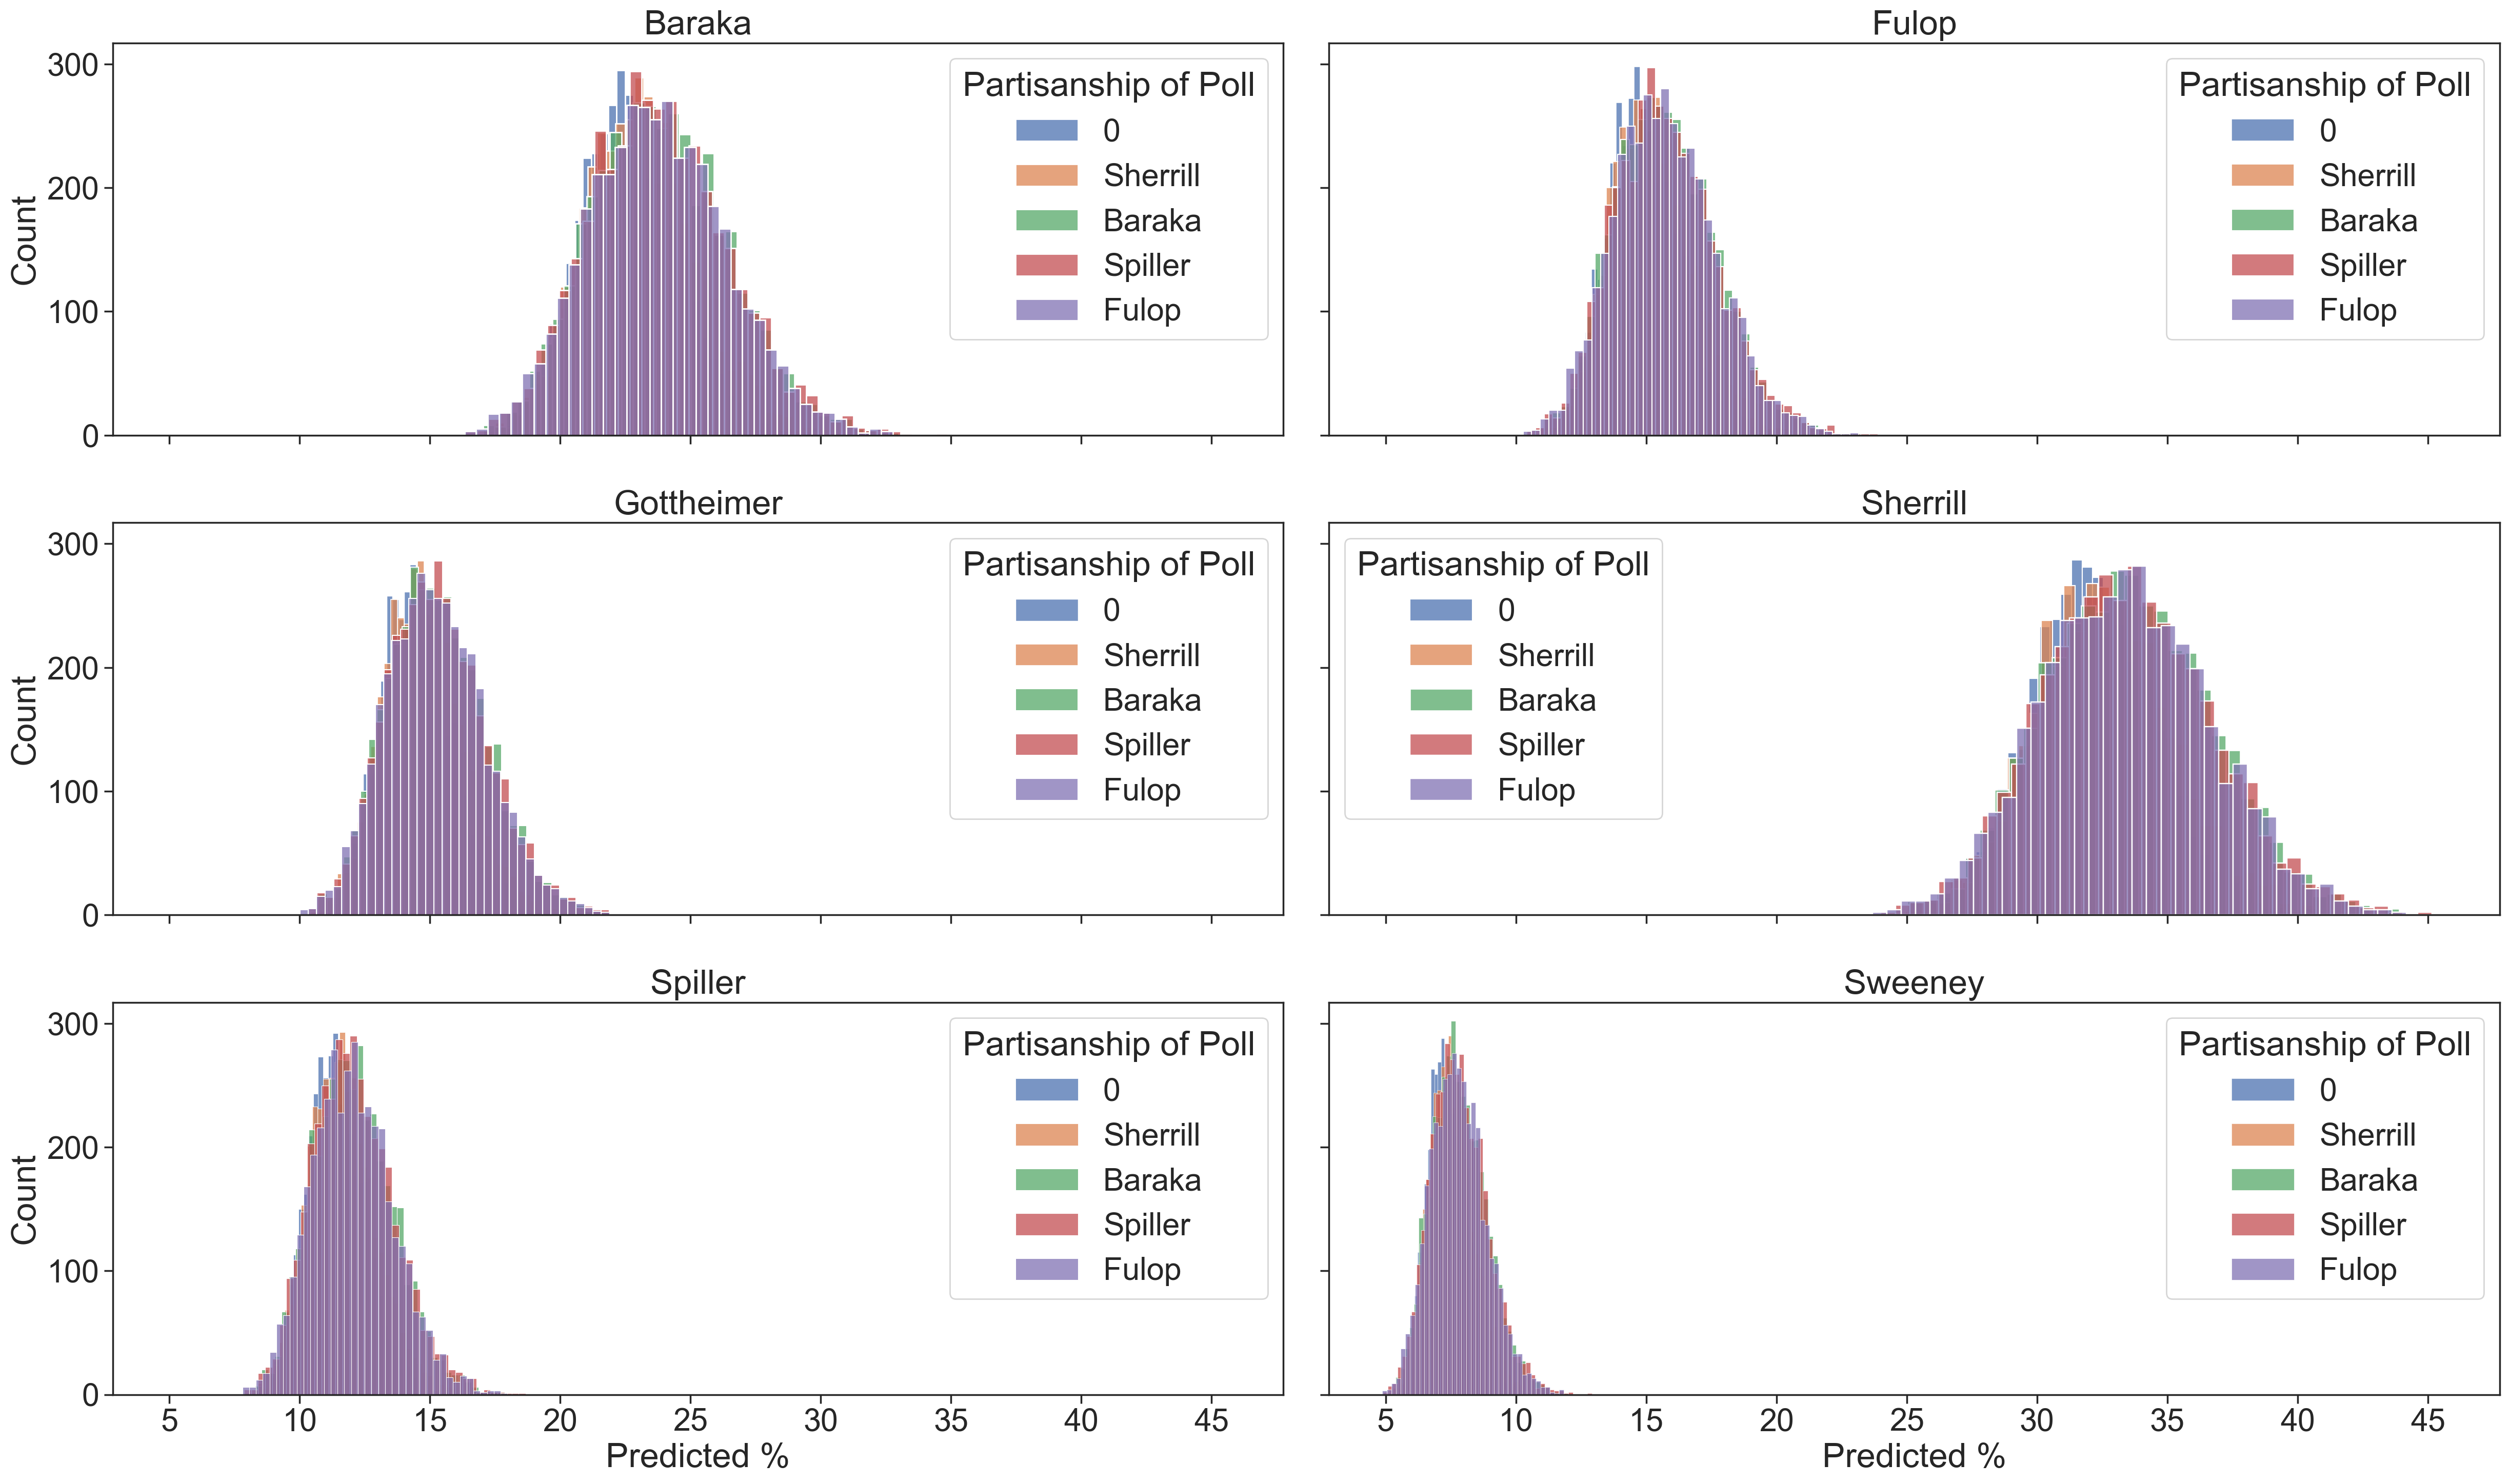

In [50]:
(fig, axs) = plt.subplots(3, 2, sharex=True, sharey=True)
for (cand, ax) in zip(partisan_cand_preds, axs.ravel()):
    for kind in partisan_cand_preds[cand]:
        sns.histplot(x=partisan_cand_preds[cand][kind] * 100, label=kind, ax=ax)
    ax.set_title(cand)
    ax.legend(title="Partisanship of Poll")
    ax.set_xlabel("Predicted %")

plt.tight_layout()

In [51]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_partisan_effect"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = post_pop.mean(axis=(0, 1, 2))

In [52]:
rows = []
for cand in partisan_cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(partisan_cand_preds[cand].values),
           "Lower" : np.quantile(partisan_cand_preds[cand], 0.025),
           "Upper" : np.quantile(partisan_cand_preds[cand], 0.975)}
    rows.append(row)
partisan_pred_df = pandas.DataFrame(rows)

In [53]:
partisan_pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
3,Sherrill,0.330226,0.313043,0.348580
0,Baraka,0.234250,0.220227,0.250207
1,Fulop,0.154756,0.144080,0.167064
2,Gottheimer,0.150121,0.139754,0.162299
4,Spiller,0.118559,0.109893,0.128477
5,Sweeney,0.076744,0.070678,0.083904


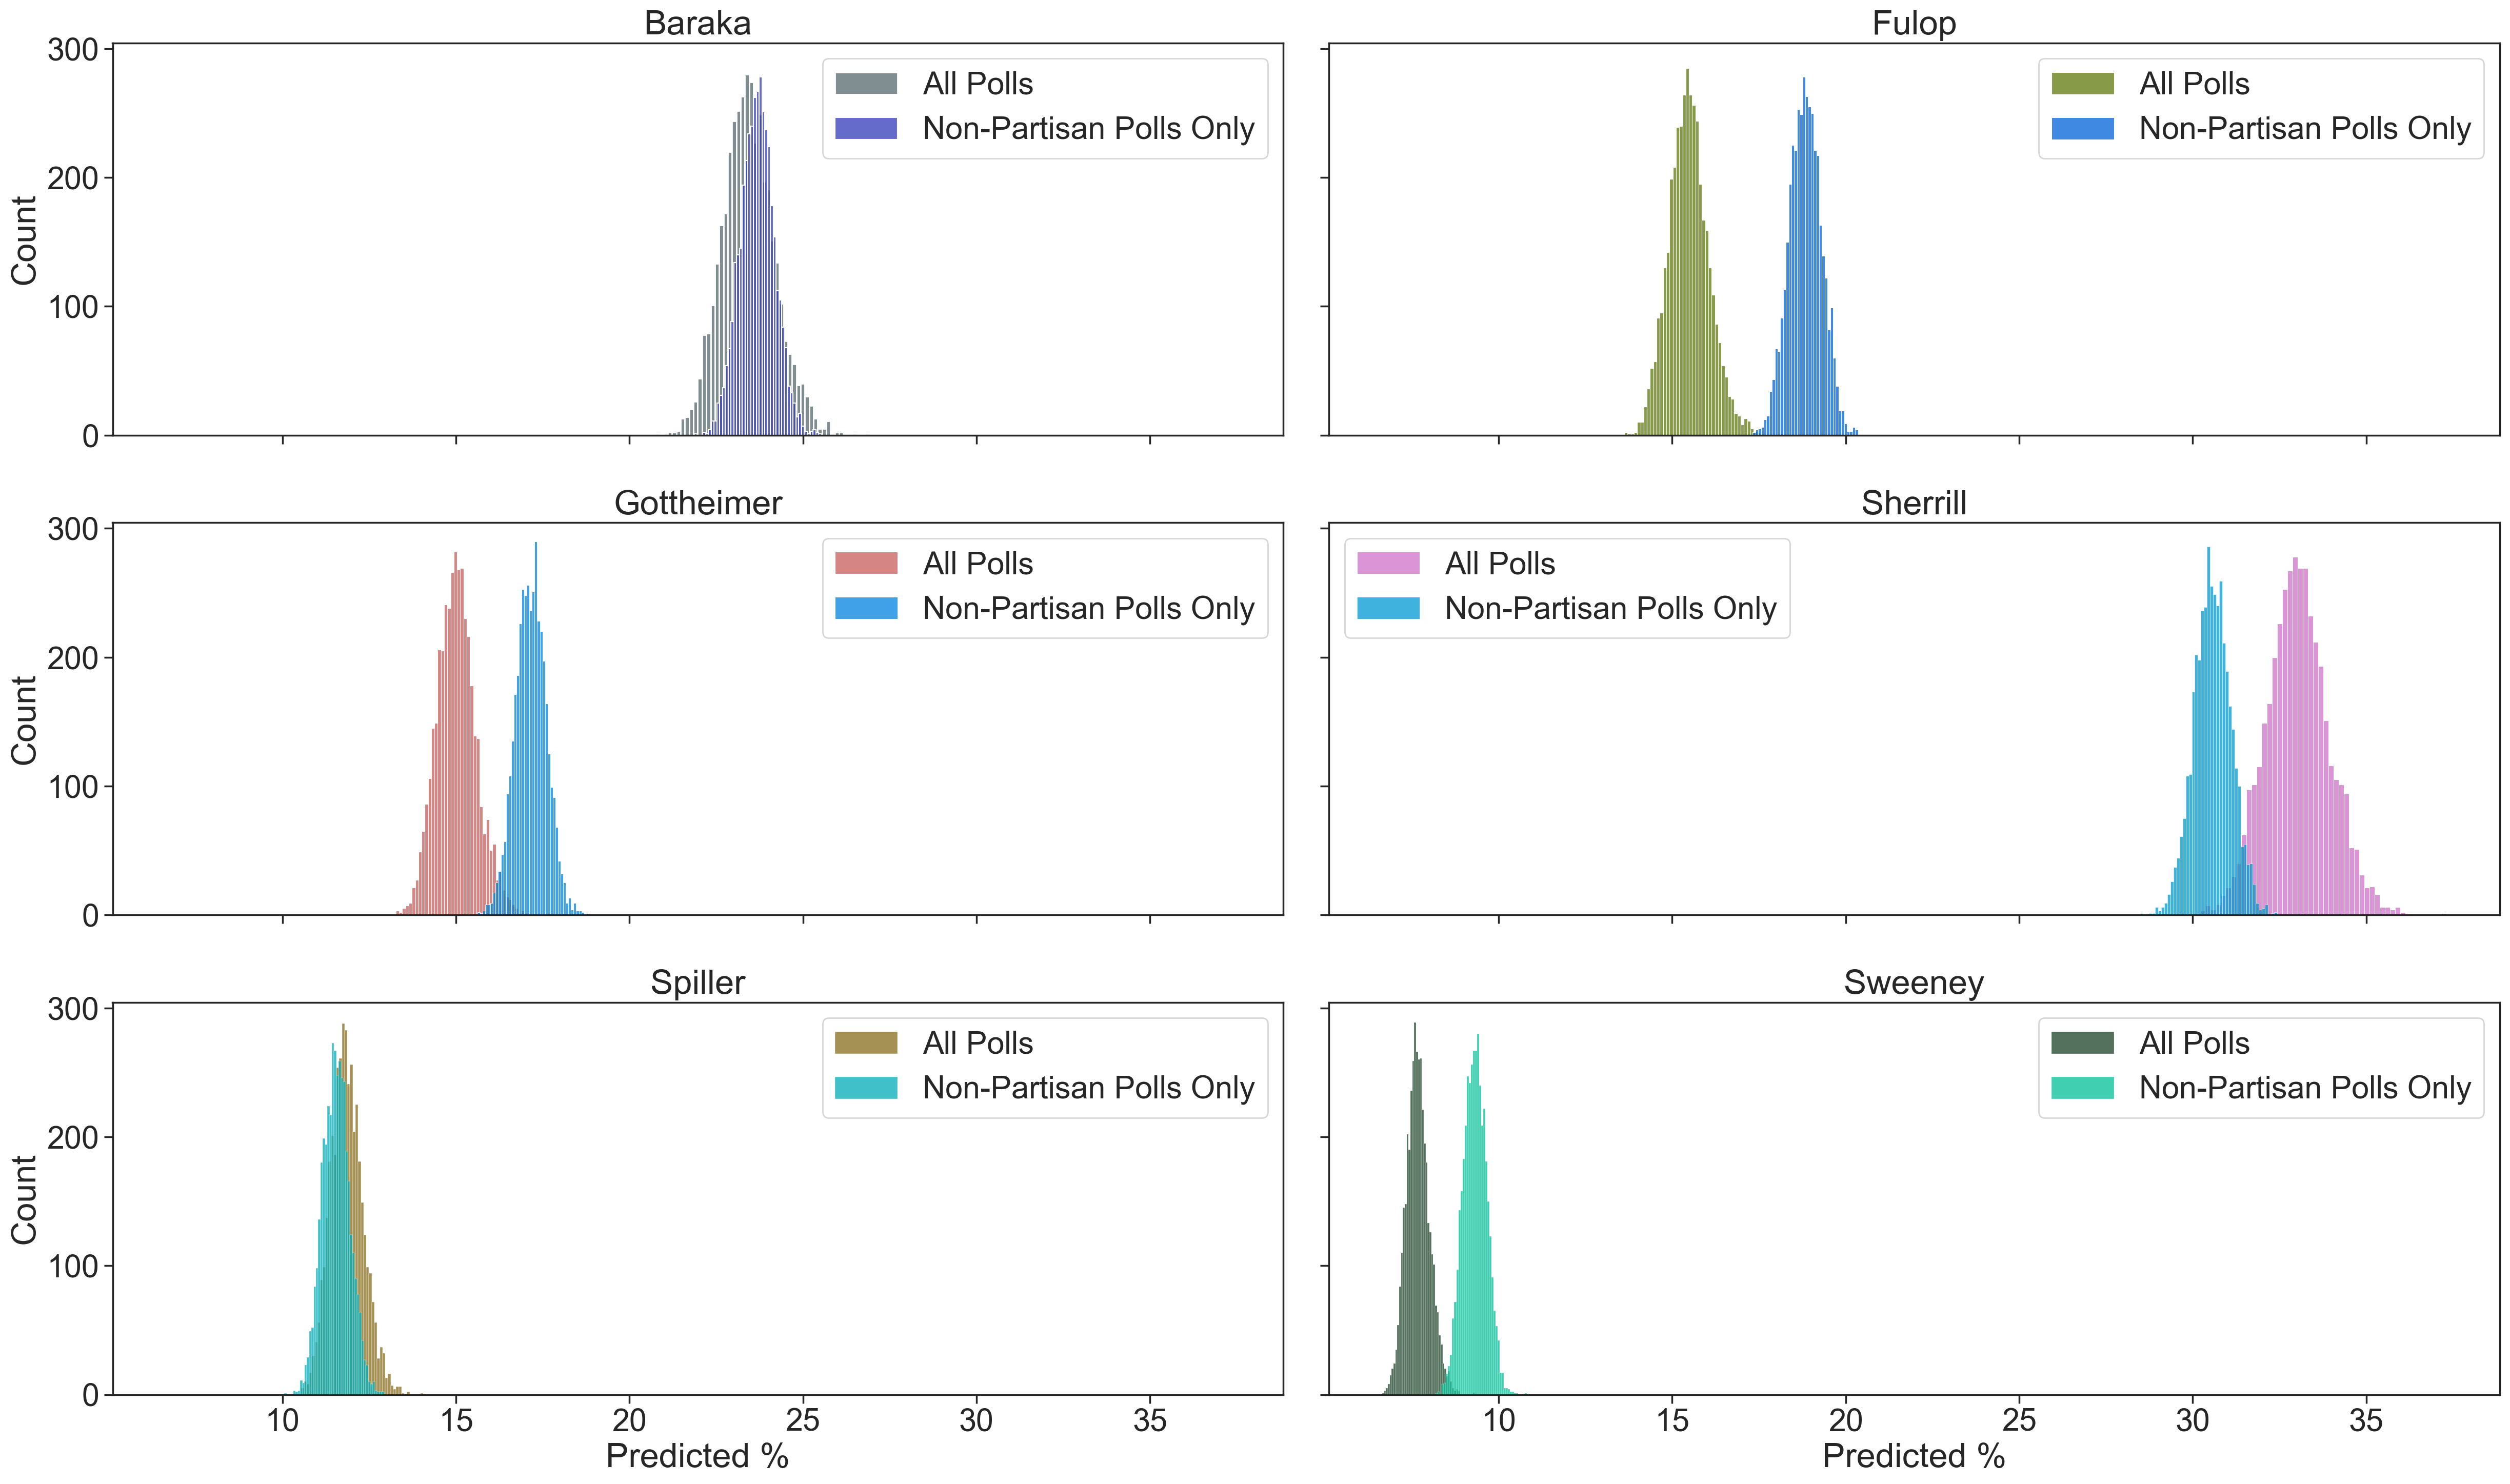

In [54]:
(fig, axs) = plt.subplots(3, 2, sharex=True, sharey=True)
np_colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]
p_colors = ["#56696C", "#5E790B", "#C85C5B", "#D071C9", "#886D1B", "#1B4127"]

for (i, (cand, ax)) in enumerate(zip(partisan_cand_preds, axs.ravel())):
    sns.histplot(x=partisan_cand_preds[cand] * 100, ax=ax, color=p_colors[i], label="All Polls")
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=np_colors[i], label="Non-Partisan Polls Only")
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")
    ax.legend()

plt.tight_layout()

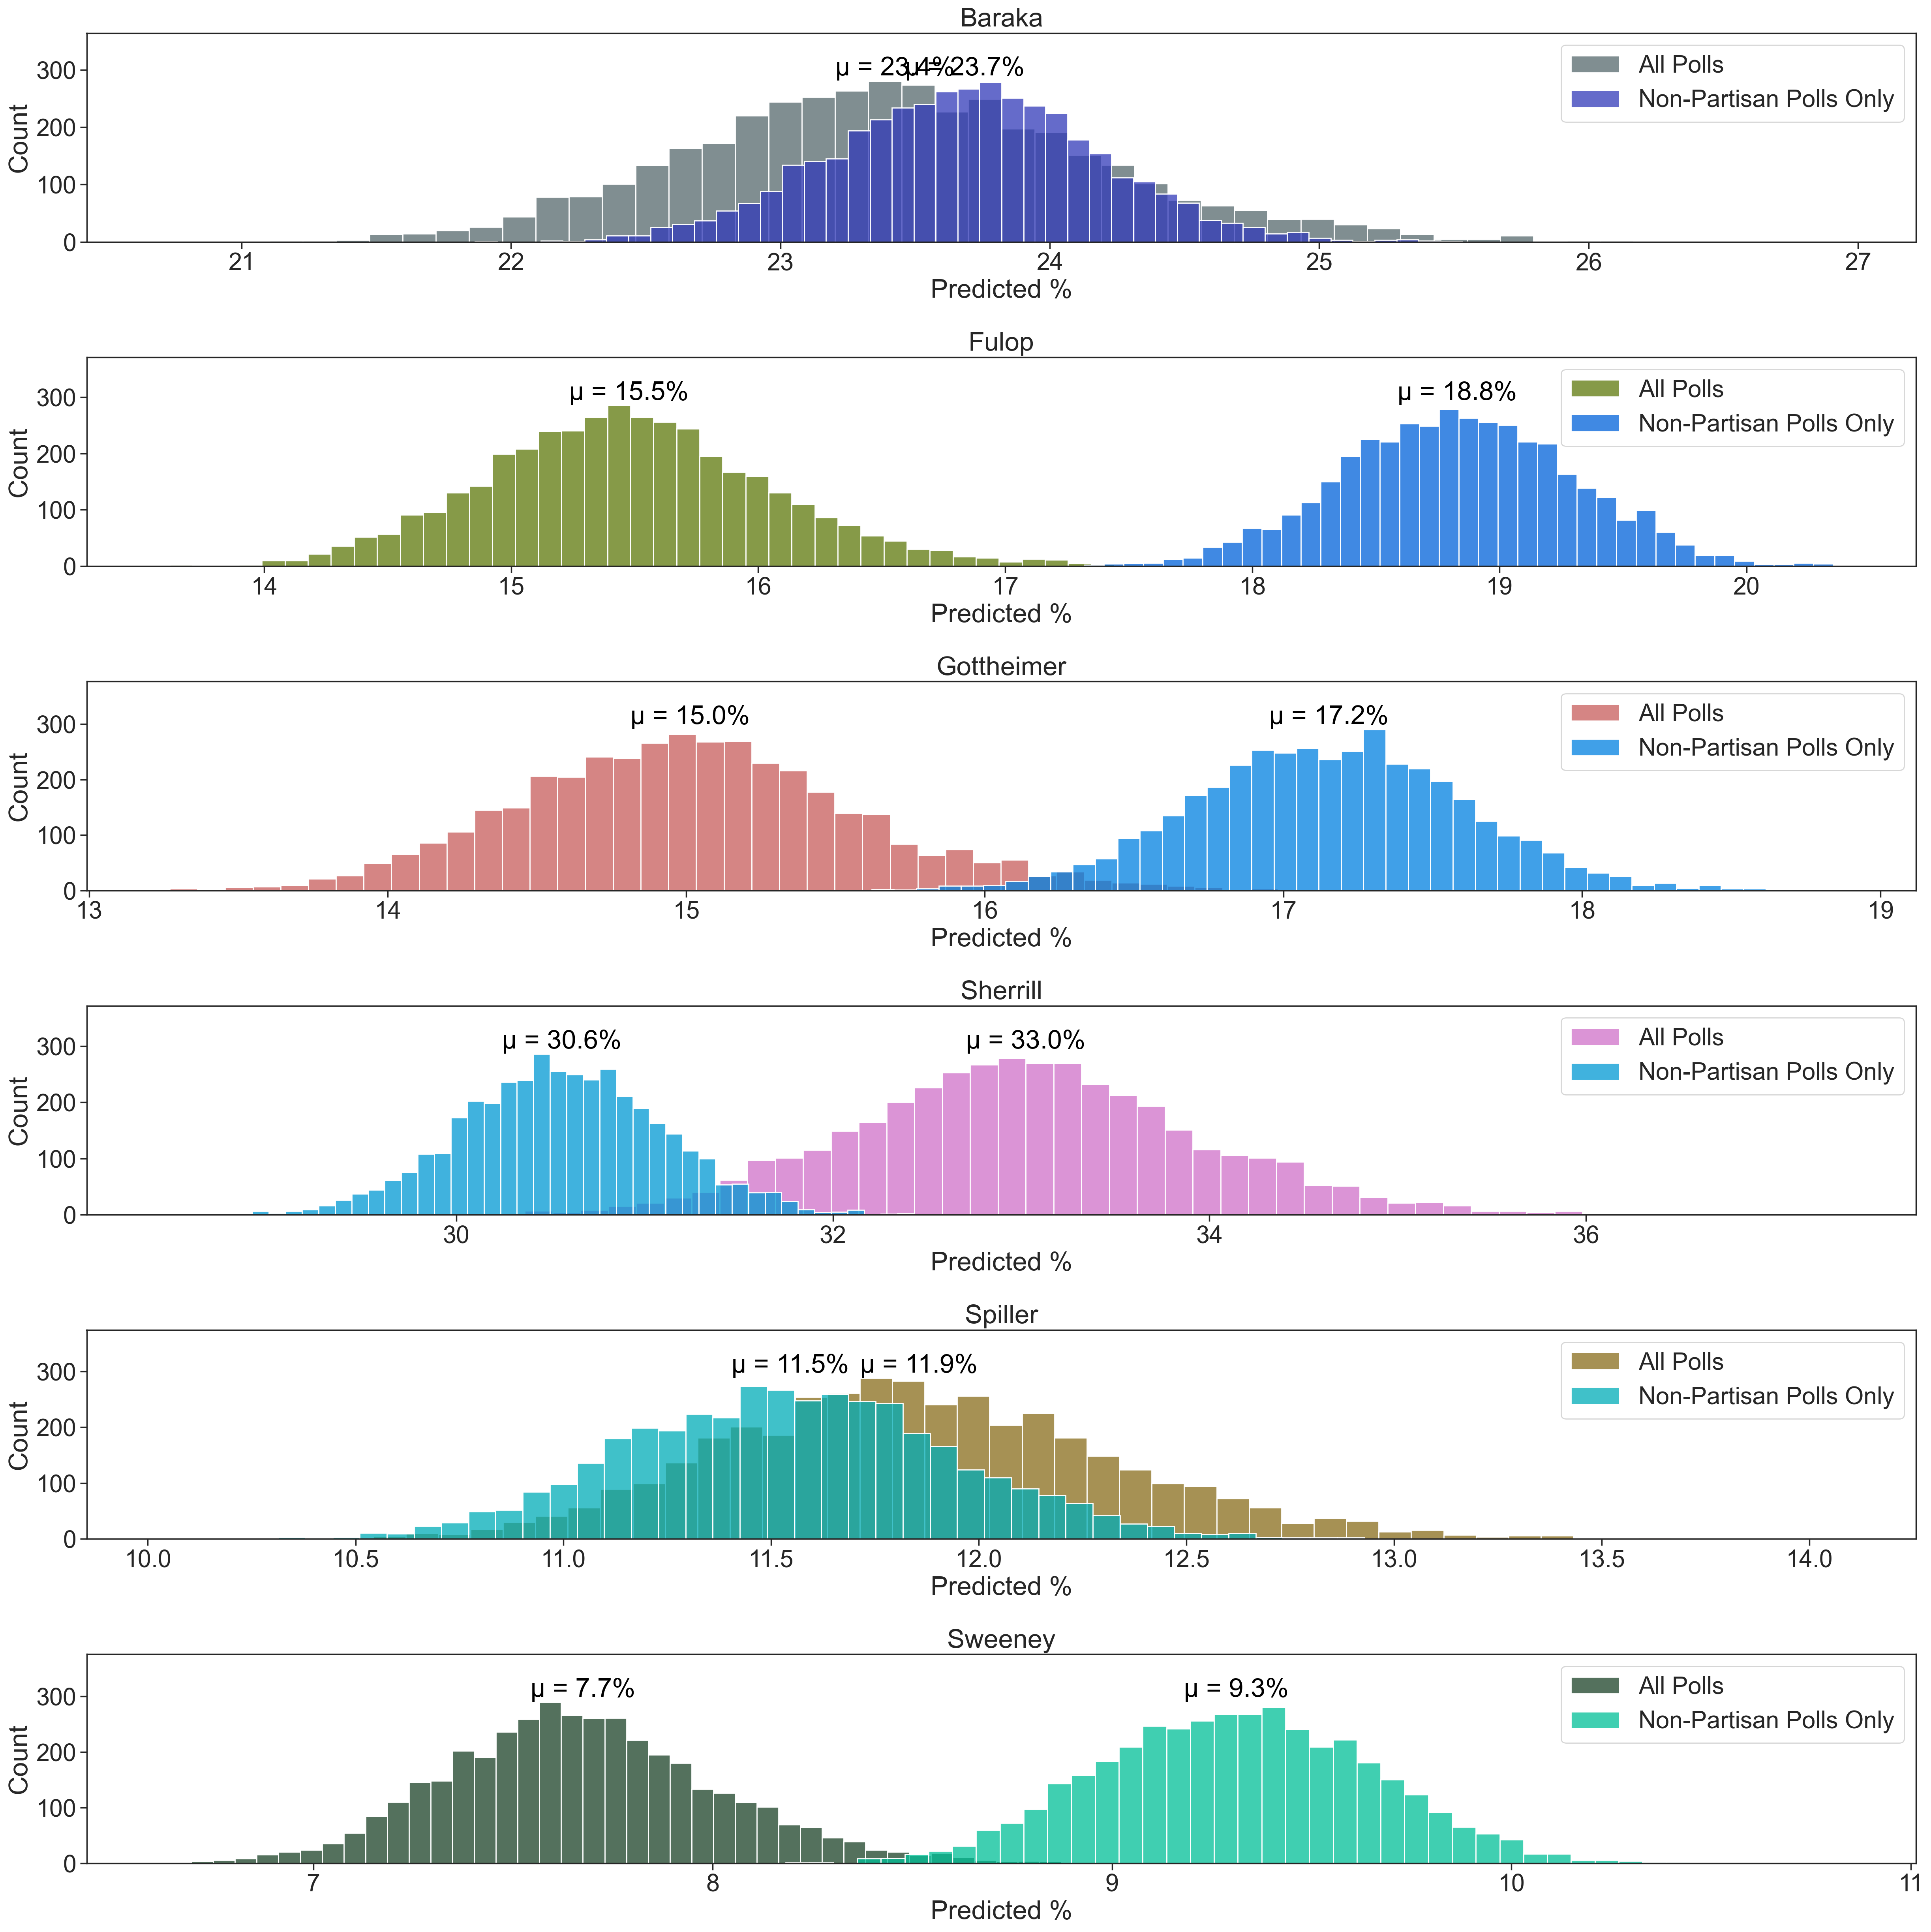

In [55]:
(fig, axs) = plt.subplots(6, 1, sharex=False, sharey=False)
fig.set_size_inches(25, 25)

np_colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]
p_colors = ["#56696C", "#5E790B", "#C85C5B", "#D071C9", "#886D1B", "#1B4127"]

for (i, (cand, ax)) in enumerate(zip(partisan_cand_preds, axs.ravel())):
    sns.histplot(x=partisan_cand_preds[cand] * 100, ax=ax, color=p_colors[i], label="All Polls")
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=np_colors[i], label="Non-Partisan Polls Only")
    preds = np_pred_df[np_pred_df["Candidate"] == cand].iloc[0] * 100
    top = max([r.get_height() for r in ax.patches])
    ax.text(preds["Pred"], top + 10, f"μ = {np.round(preds['Pred'], 1)}%", color="black", ha="center")
    preds = partisan_pred_df[partisan_pred_df["Candidate"] == cand].iloc[0] * 100
    ax.text(preds["Pred"], top + 10, f"μ = {np.round(preds['Pred'], 1)}%", color="black", ha="center")
    ax.margins(y=0.3)
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")
    ax.legend()

plt.tight_layout()